## EEG


In [28]:
import re
import math
import json
import numpy as np
import pandas as pd
from pathlib import Path
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import GroupShuffleSplit
import ptitprince as pt
import matplotlib.pyplot as plt
import seaborn as sns
import ast
%matplotlib inline

In [29]:
def parse_num_list(value):
    if pd.isna(value):
        return None
    text = str(value).strip()
    if not text:
        return None
    if text[0] == "[" and text[-1] == "]":
        text = text[1:-1]
    tokens = text.replace(",", " ").split()
    if not tokens:
        return None
    try:
        return np.asarray(tokens, dtype=np.float32)
    except ValueError:
        return None


def fix_len(arr, n):
    if arr is None:
        return None
    if arr.size == n:
        return arr.astype(np.float32)
    if arr.size > n:
        return arr[:n].astype(np.float32)
    out = np.zeros(n, dtype=np.float32)
    out[: arr.size] = arr
    return out


def power_to_seq(power, n=512):
    if power is None:
        return None
    power = fix_len(power, 8)
    x_old = np.arange(8, dtype=np.float32)
    x_new = np.linspace(0, 7, n, dtype=np.float32)
    return np.interp(x_new, x_old, power).astype(np.float32)

LABELS_JSON_PATH = Path("labels.json")
if not LABELS_JSON_PATH.exists():
    raise FileNotFoundError(f"Missing label mapping file: {LABELS_JSON_PATH}")

_RAW_LABEL_MAP = json.loads(LABELS_JSON_PATH.read_text(encoding="utf-8"))
LABELS = 9
if LABELS == 9:
    # Map to 9 major classes.
    _RAW_LABEL_MAP = _RAW_LABEL_MAP.get("labels_9", {})
elif LABELS == 19:
    # Map to 19 classes (mostly 1-to-1 with raw labels).
    _RAW_LABEL_MAP = _RAW_LABEL_MAP.get("labels_19", {})
else:
    raise ValueError(f"Unsupported number of labels: {LABELS}")

def _resolve_label_once(src: str, label_map: dict, cache: dict) -> str:
    if src in cache:
        return cache[src]

    seen = set()
    cur = src
    while cur in label_map and cur not in seen:
        seen.add(cur)
        cur = label_map[cur]

    cache[src] = cur
    return cur


# Flatten any chained mappings exactly once for O(1) runtime lookup.
_RESOLVED_LABEL_MAP = {}
for _key in _RAW_LABEL_MAP:
    _resolve_label_once(_key, _RAW_LABEL_MAP, _RESOLVED_LABEL_MAP)

# Optional case-insensitive support.
_RESOLVED_LABEL_MAP_LOWER = {k.lower(): v for k, v in _RESOLVED_LABEL_MAP.items()}


def to_major_class(label: str) -> str:
    s = str(label).strip()
    if not s:
        return s

    mapped = _RESOLVED_LABEL_MAP.get(s)
    if mapped is not None:
        return mapped

    mapped = _RESOLVED_LABEL_MAP_LOWER.get(s.lower())
    if mapped is not None:
        return mapped

    # Fast fallback for unseen labels.
    base = re.split(r"[-_]", s)[0]
    base = re.sub(r"\d+$", "", base)
    return base or s

In [30]:
RAW_PATH = Path("EEG/eeg-data.csv")
eeg_data = pd.read_csv(RAW_PATH, converters={"eeg_power": parse_num_list, "raw_values": parse_num_list})
original_size = eeg_data.shape[0]
print(f"Original size of the dataset: {original_size}")

eeg_data = eeg_data[eeg_data.label != 'unlabeled']
print(f"Size of the dataset after removing unlabeled data: {eeg_data.shape[0]}")
eeg_data = eeg_data[eeg_data['signal_quality'] <= 128].copy()
print(f"Data loss percentage: {(1 - eeg_data.shape[0] / original_size) * 100:.2f}%")

# Filtering useful columns 
eeg_data = eeg_data[['id', 'eeg_power', 'raw_values', 'label']]
print("Data shape after dropping unnecessary columns and low quality signals:", eeg_data.shape)

# Power bands
POWER_BANDS = ['delta', 'theta', 'low_alpha', 'high_alpha', 'low_beta', 'high_beta', 'low_gamma', 'mid_gamma']
for i, band in enumerate(POWER_BANDS):
    eeg_data[band] = eeg_data['eeg_power'].apply(lambda x: x[i] if x is not None and len(x) > i else np.nan)
# eeg_data.drop(columns=['eeg_power'], inplace=True)
# print("\nAfter separating power bands:")
print(eeg_data.shape)
display(eeg_data.head(1))

color_map = {}
for label in eeg_data.label.unique():
    color_map[label] = np.random.rand(3,)

# plt.figure(figsize=(10, 10))
# # Compute one scalar per sample to avoid ambiguous comparisons on array-like cells.
# sample_max_power = eeg_data['eeg_power'].apply(lambda x: np.max(x) if x is not None and len(x) else np.nan)
# plt.scatter(eeg_data.id, sample_max_power, c=eeg_data.label.map(color_map))
# plt.xlabel("ID")

print("Columns:", eeg_data.columns)

# def extract_eeg_lists(eeg_power_str): # Runs faster thatn ast.literal_eval() and eval()
#     return [float(n) for n in eeg_power_str.split("[")[1].split("]")[0].split(",")]
# eeg_data.eeg_power = eeg_data.eeg_power.apply(extract_eeg_lists)
# eeg_data.raw_values = eeg_data.raw_values.apply(extract_eeg_lists)


KeyboardInterrupt: 

# FFT of raw EEG values


In [ ]:
# FFT-based features for all rows (from raw_values)
def fft_feature_row(raw_signal, fs_hz):
    feature_template = {
        'fft_dominant_freq_hz': np.nan,
        'fft_spectral_centroid_hz': np.nan,
        'fft_spectral_entropy': np.nan,
        'fft_power_delta': np.nan,
        'fft_power_theta': np.nan,
        'fft_power_alpha': np.nan,
        'fft_power_beta': np.nan,
        'fft_power_gamma': np.nan,
    }

    if raw_signal is None:
        return feature_template

    x = np.asarray(raw_signal, dtype=np.float32)
    if x.ndim != 1 or x.size < 4:
        return feature_template

    x = x - x.mean()
    n = x.size
    freqs = np.fft.rfftfreq(n, d=1.0 / fs_hz)
    psd = (np.abs(np.fft.rfft(x)) ** 2) / n

    if psd.size < 2:
        return feature_template

    # Ignore DC component for descriptive spectral features.
    psd_no_dc = psd.copy()
    psd_no_dc[0] = 0.0
    total_power = float(psd_no_dc.sum())

    if total_power <= 0.0:
        return feature_template

    dominant_idx = int(np.argmax(psd_no_dc))
    dominant_freq = float(freqs[dominant_idx])
    spectral_centroid = float(np.sum(freqs * psd_no_dc) / total_power)

    p = psd_no_dc / total_power
    p = p[p > 0]
    spectral_entropy = float(-(p * np.log2(p)).sum() / np.log2(len(psd_no_dc))) if len(psd_no_dc) > 1 else np.nan

    def band_power(lo_hz, hi_hz):
        mask = (freqs >= lo_hz) & (freqs < hi_hz)
        if not np.any(mask):
            return np.nan
        return float(psd_no_dc[mask].sum())

    return {
        'fft_dominant_freq_hz': dominant_freq,
        'fft_spectral_centroid_hz': spectral_centroid,
        'fft_spectral_entropy': spectral_entropy,
        'fft_power_delta': band_power(0.5, 4.0),
        'fft_power_theta': band_power(4.0, 8.0),
        'fft_power_alpha': band_power(8.0, 13.0),
        'fft_power_beta': band_power(13.0, 30.0),
        'fft_power_gamma': band_power(30.0, 45.0),
    }

if 'FFT_SAMPLE_RATE_HZ' not in globals():
    FFT_SAMPLE_RATE_HZ = 512  # Set to your actual sampling rate if different.

fft_feature_cols = [
    'fft_dominant_freq_hz',
    'fft_spectral_centroid_hz',
    'fft_spectral_entropy',
    'fft_power_delta',
    'fft_power_theta',
    'fft_power_alpha',
    'fft_power_beta',
    'fft_power_gamma',
]

# Safe re-run: remove old FFT feature columns before recomputing.
eeg_data = eeg_data.drop(columns=[c for c in fft_feature_cols if c in eeg_data.columns], errors='ignore')

fft_feature_series = eeg_data['raw_values'].apply(lambda x: fft_feature_row(x, FFT_SAMPLE_RATE_HZ))
fft_feature_df = pd.DataFrame(fft_feature_series.tolist(), index=eeg_data.index)
eeg_data = pd.concat([eeg_data, fft_feature_df], axis=1)

display(eeg_data.head(1))
print(f"Added FFT features for {len(eeg_data)} rows using fs={FFT_SAMPLE_RATE_HZ} Hz")
print("new shape after FFT:", eeg_data.shape)

,id,eeg_power,raw_values,label,delta,theta,low_alpha,high_alpha,low_beta,high_beta,low_gamma,mid_gamma,fft_dominant_freq_hz,fft_spectral_centroid_hz,fft_spectral_entropy,fft_power_delta,fft_power_theta,fft_power_alpha,fft_power_beta,fft_power_gamma
13017,7,"[56887.0, 45471.0, 20074.0, 5359.0, 22594.0, 7...","[99.0, 96.0, 91.0, 89.0, 91.0, 89.0, 87.0, 93....",blinkInstruction,56887.0,45471.0,20074.0,5359.0,22594.0,7867.0,9437.0,3238.0,3.0,4.445884,0.341049,2620048.0,843675.875,151849.84375,97824.140625,19451.005859


Added FFT features for 9954 rows using fs=512 Hz
new shape after FFT: (9954, 20)


In [ ]:
eeg_data.columns

Index(['id', 'eeg_power', 'raw_values', 'label', 'delta', 'theta', 'low_alpha',
       'high_alpha', 'low_beta', 'high_beta', 'low_gamma', 'mid_gamma',
       'fft_dominant_freq_hz', 'fft_spectral_centroid_hz',
       'fft_spectral_entropy', 'fft_power_delta', 'fft_power_theta',
       'fft_power_alpha', 'fft_power_beta', 'fft_power_gamma'],
      dtype='object')

In [ ]:
print(f"Number of IDs: {len(list(eeg_data.id.value_counts().keys()))}")
print(f"Number of labels: {len(list(eeg_data.label.value_counts().keys()))}")

Number of IDs: 30
Number of labels: 67


# Labels


In [ ]:
eeg_data['label'] = eeg_data['label'].map(to_major_class)
eeg_data.reset_index(inplace=True)
print(f"Data shape after collating minor classes into major ones: {eeg_data.shape}")
print(f"Columns: {eeg_data.columns}")
print(f"Unique classes after collating minor classes into major ones: \t{len(eeg_data['label'].unique())}")

Data shape after collating minor classes into major ones: (9954, 21)
Columns: Index(['index', 'id', 'eeg_power', 'raw_values', 'label', 'delta', 'theta',
       'low_alpha', 'high_alpha', 'low_beta', 'high_beta', 'low_gamma',
       'mid_gamma', 'fft_dominant_freq_hz', 'fft_spectral_centroid_hz',
       'fft_spectral_entropy', 'fft_power_delta', 'fft_power_theta',
       'fft_power_alpha', 'fft_power_beta', 'fft_power_gamma'],
      dtype='object')
Unique classes after collating minor classes into major ones: 	9


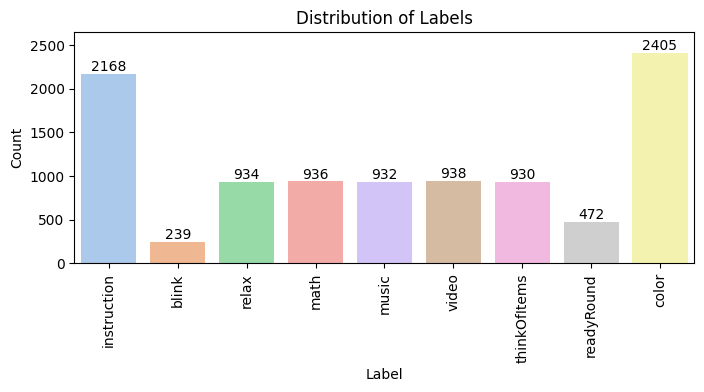

In [ ]:
plt.figure(figsize=(8, 3))
sns.countplot(x='label', data=eeg_data, palette='pastel', hue='label')
for label in eeg_data.label.value_counts().keys():
    count = eeg_data[eeg_data.label == label].shape[0]
    plt.text(label, count, str(count), ha='center', va='bottom', rotation=0)
plt.title('Distribution of Labels')
plt.xlabel('Label')
plt.ylabel('Count')
plt.xticks(rotation=90)
plt.ylim(0, max(eeg_data['label'].value_counts()) * 1.1)
plt.show()

In [ ]:
def summarize_vector(values, prefix):
    arr = np.asarray(values, dtype=float)
    if arr.size == 0:
        return {
            f"{prefix}_len": 0.0,
            f"{prefix}_mean": np.nan,
            f"{prefix}_std": np.nan,
            f"{prefix}_min": np.nan,
            f"{prefix}_max": np.nan,
            f"{prefix}_median": np.nan,
            f"{prefix}_q05": np.nan,
            f"{prefix}_q95": np.nan,
            f"{prefix}_abs_mean": np.nan,
            f"{prefix}_clip_ratio": np.nan,
        }

    return {
        f"{prefix}_len": float(arr.size),
        f"{prefix}_mean": float(arr.mean()),
        f"{prefix}_std": float(arr.std()),
        f"{prefix}_min": float(arr.min()),
        f"{prefix}_max": float(arr.max()),
        f"{prefix}_median": float(np.median(arr)),
        f"{prefix}_q05": float(np.quantile(arr, 0.05)),
        f"{prefix}_q95": float(np.quantile(arr, 0.95)),
        f"{prefix}_abs_mean": float(np.mean(np.abs(arr))),
        f"{prefix}_clip_ratio": float(np.mean(np.abs(arr) >= 2047.0)),
    }

# Sample power and raw values


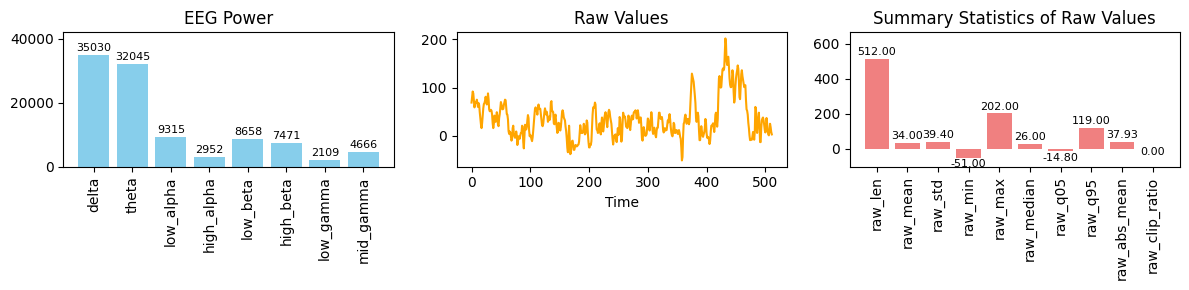

In [ ]:
random_index = np.random.choice(eeg_data.index)
fig, axs = plt.subplots(1, 3, figsize=(12, 3))

axs[0].bar(POWER_BANDS, eeg_data.loc[random_index, POWER_BANDS], color='skyblue')
for p in axs[0].patches:
    axs[0].annotate(f'{p.get_height():.0f}', (p.get_x() + p.get_width() / 2., p.get_height()),
                    ha='center', va='center', fontsize=8, color='black', xytext=(0, 5),
                    textcoords='offset points')
axs[0].set_title('EEG Power')
axs[0].set_ylim(0, max(eeg_data.loc[random_index, POWER_BANDS]) * 1.2)
axs[0].set_xticks(range(len(POWER_BANDS)))
axs[0].set_xticklabels(POWER_BANDS, rotation=90)

axs[1].plot(eeg_data.loc[random_index, 'raw_values'], label='Raw Values', color='orange')
axs[1].set_title('Raw Values')
axs[1].set_xlabel('Time')

raw_features = summarize_vector(eeg_data.loc[random_index, 'raw_values'], 'raw')
axs[2].bar(raw_features.keys(), raw_features.values(), color='lightcoral')
for i, value in enumerate(raw_features.values()):
    axs[2].text(i, value + math.copysign(10, value),
                f'{value:.2f}', ha='center', va='bottom' if value > 0 else 'top', fontsize=8)
axs[2].set_title('Summary Statistics of Raw Values')
axs[2].set_xticks(range(len(raw_features.keys())))
axs[2].set_xticklabels(raw_features.keys(), rotation=90)
axs[2].set_ylim(min(raw_features.values()) * 2, max(raw_features.values()) * 1.3)

plt.tight_layout()
plt.show()

In [ ]:
raw_features

{'raw_len': 512.0,
 'raw_mean': 34.001953125,
 'raw_std': 39.404131040543234,
 'raw_min': -51.0,
 'raw_max': 202.0,
 'raw_median': 26.0,
 'raw_q05': -14.799999999999997,
 'raw_q95': 119.0,
 'raw_abs_mean': 37.927734375,
 'raw_clip_ratio': 0.0}

In [ ]:
print(f"{len(POWER_BANDS)} power bands + {len(fft_feature_cols)} FFT features + {len(raw_features)} raw value summary features = {len(POWER_BANDS) + len(fft_feature_cols) + len(raw_features)} total features")

8 power bands + 8 FFT features + 10 raw value summary features = 26 total features


In [ ]:
for stat in raw_features.keys():
    eeg_data[f'{stat}'] = eeg_data['raw_values'].apply(lambda x: summarize_vector(x, 'raw')[stat] if x is not None else np.nan)

print("Shape after adding raw value features:", eeg_data.shape)
print("Columns after adding raw value features:", eeg_data.columns)

Shape after adding raw value features: (9954, 31)
Columns after adding raw value features: Index(['index', 'id', 'eeg_power', 'raw_values', 'label', 'delta', 'theta',
       'low_alpha', 'high_alpha', 'low_beta', 'high_beta', 'low_gamma',
       'mid_gamma', 'fft_dominant_freq_hz', 'fft_spectral_centroid_hz',
       'fft_spectral_entropy', 'fft_power_delta', 'fft_power_theta',
       'fft_power_alpha', 'fft_power_beta', 'fft_power_gamma', 'raw_len',
       'raw_mean', 'raw_std', 'raw_min', 'raw_max', 'raw_median', 'raw_q05',
       'raw_q95', 'raw_abs_mean', 'raw_clip_ratio'],
      dtype='object')


# OR Load the fully-featured, cleaned dataset:

In [ ]:
eeg_data.to_csv("EEG/eeg_data_with_features.csv", index=False)
eeg_data = pd.read_csv("EEG/eeg_data_with_features.csv", converters={"eeg_power": parse_num_list, "raw_values": parse_num_list})
print("Shape after reloading from CSV:", eeg_data.shape)

Row index: 1450


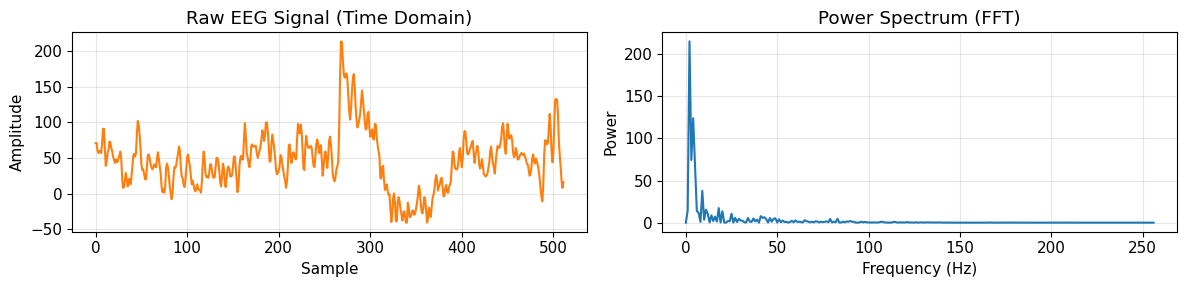

In [ ]:
def compute_fft(raw_signal, fs_hz):
    x = np.asarray(raw_signal, dtype=np.float32)
    if x.ndim != 1 or x.size < 2:
        raise ValueError("raw_signal must be a 1D array-like with at least 2 samples.")

    # Remove DC offset so low-frequency energy is easier to interpret.
    x = x - x.mean()
    n = x.size

    freqs = np.fft.rfftfreq(n, d=1.0 / fs_hz)
    spectrum = np.fft.rfft(x)
    amplitude = np.abs(spectrum) / n
    power = amplitude ** 2
    return freqs, amplitude, power

random_index = np.random.choice(eeg_data.index)
raw_signal = eeg_data.loc[random_index, 'raw_values']

if 'FFT_SAMPLE_RATE_HZ' not in globals():
    FFT_SAMPLE_RATE_HZ = 512  # Set to your actual sampling rate if different.

freqs, amplitude, power = compute_fft(raw_signal, FFT_SAMPLE_RATE_HZ)

print(f"Row index: {random_index}")
# print(f"Dominant frequency: {eeg_data['fft_dominant_freq_hz'][random_index]:.2f} Hz")

fig, axs = plt.subplots(1,2, figsize=(12, 3))
axs[0].plot(raw_signal, color='tab:orange')
axs[0].set_title('Raw EEG Signal (Time Domain)')
axs[0].set_xlabel('Sample')
axs[0].set_ylabel('Amplitude')
axs[0].grid(alpha=0.3)

axs[1].plot(freqs,power, color='tab:blue')
axs[1].set_title('Power Spectrum (FFT)')
axs[1].set_xlabel('Frequency (Hz)')
axs[1].set_ylabel('Power')
# axs[1].set_xlim(0, FFT_SAMPLE_RATE_HZ / 2)
axs[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

### To further preprocess the data, all these raw value stats could be considered as additional features (new columns).

### Then, train/val/test split for some initial model development and evaluation.

### Class (label) balance is very important, also subject leakage!

### More advanced models (CNN, RNN, Transformer) could be also developed without these features.


### Exploratory Data Analysis (EDA)

In [54]:
def plot_distribution(data=eeg_data, ncols=1, collection=None):
    large = False
    if collection is None:
        return
    elif collection == 'RAW':
        inferred_cols = [f"{stat}" for stat in raw_features.keys()]
        # Exclude len and clip_ratio as they are all identical (512, 0.0, respectively) across samples and classes.
        columns = [col for col in inferred_cols if col in data.columns][1:-1] 
    elif collection == 'POWER':
        columns = [band for band in POWER_BANDS if band in data.columns]
        large=True
    elif collection == 'FFT':
        columns = [col for col in fft_feature_cols if col in data.columns]

    if not columns:
        raise ValueError("No feature columns were found to plot.")

    classes = data['label'].dropna().unique().tolist()
    n_panels = len(columns)
    nrows = math.ceil(n_panels / ncols)
    fig, axs = plt.subplots(
        nrows,
        ncols,
        figsize=(9,12),
        # squeeze=False,
        sharex=True
    )
    axs = axs.flatten()

    plt.rcParams.update({'font.size': 11})

    for i, feature in enumerate(columns):
        ax = axs[i]
        rows = []

        for cls in classes:
            class_values = data.loc[data['label'] == cls, feature].dropna().astype(float)
            rows.extend({'label': cls, 'value': value} for value in class_values)

        if not rows:
            ax.set_title(f"{feature} (no data)")
            ax.axis('off')
            continue

        feature_df = pd.DataFrame(rows)

        pt.RainCloud(
            data=feature_df,
            x='label',
            y='value',
            orient='v',
            hue='label',
            width_viol=0.6,
            width_box=0.2,
            move=0.2,
            alpha=0.6,
            point_size=1.2,
            ax=ax
        )

        pretty_name = feature.replace('_', ' ').title()
        # ax.set_title(pretty_name)
        ax.set_xlabel('')
        ax.set_ylabel(pretty_name, fontsize=9)
        if large:ax.set_ylabel(f'{POWER_BANDS[i].replace('_', ' ').title()} (1e5)', fontsize=9)
        ax.grid(axis='y', alpha=0.2, linestyle='--')

        if ax.get_legend() is not None:
            ax.get_legend().remove()
            
    # Format all y-axes to display in 1e5 units
    from matplotlib.ticker import FuncFormatter
    def format_1e5(x, pos):
        return f'{x/1e5:.0f}'

    for ax in axs:
        if large:
            ax.yaxis.set_major_formatter(FuncFormatter(format_1e5))

    for ax in axs[n_panels:]:
        ax.axis('off')

    last_row_start = max(0, (nrows - 1) * ncols)
    for ax in axs[last_row_start:last_row_start + ncols]:
        if ax.has_data():
            ax.tick_params(axis='x', rotation=0, labelsize=9)

    plt.tight_layout()
    plt.show()

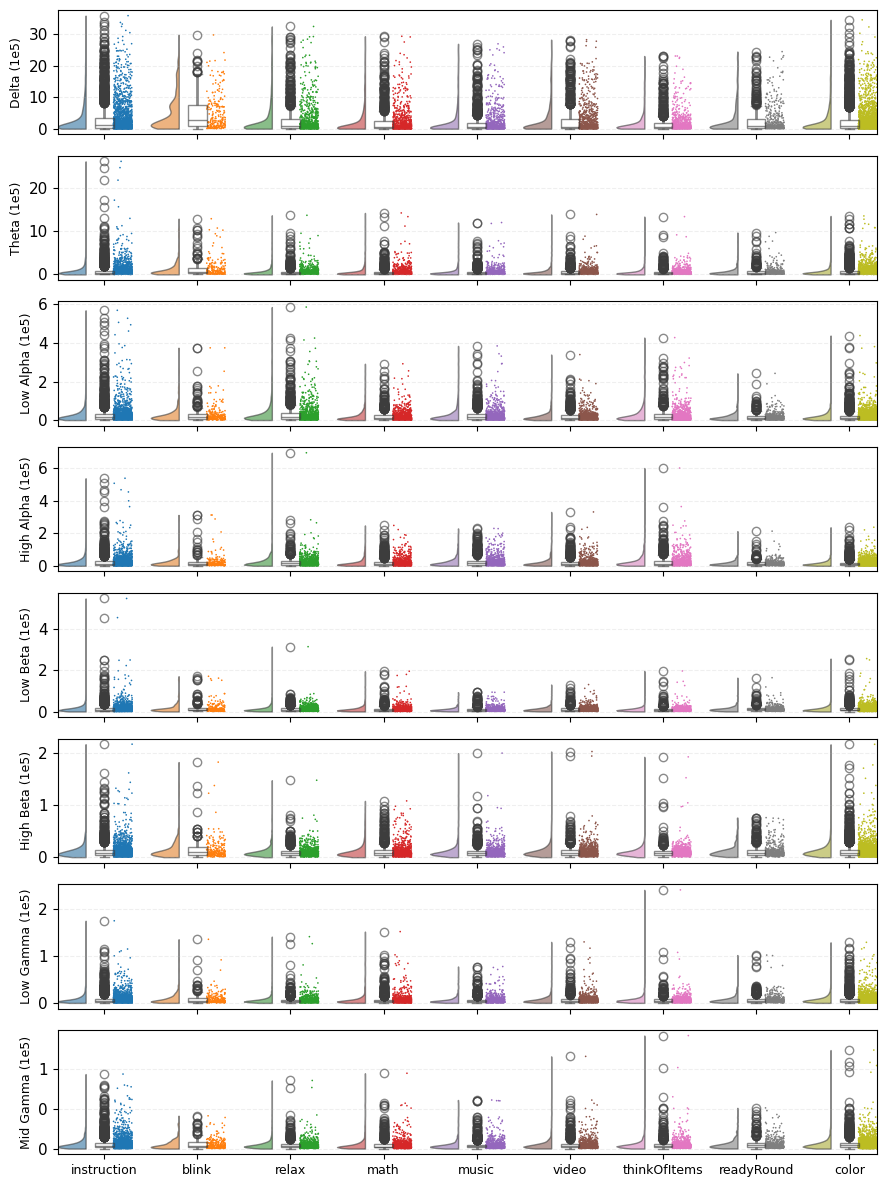

In [52]:
plot_distribution(data=eeg_data, ncols=1, collection='POWER')

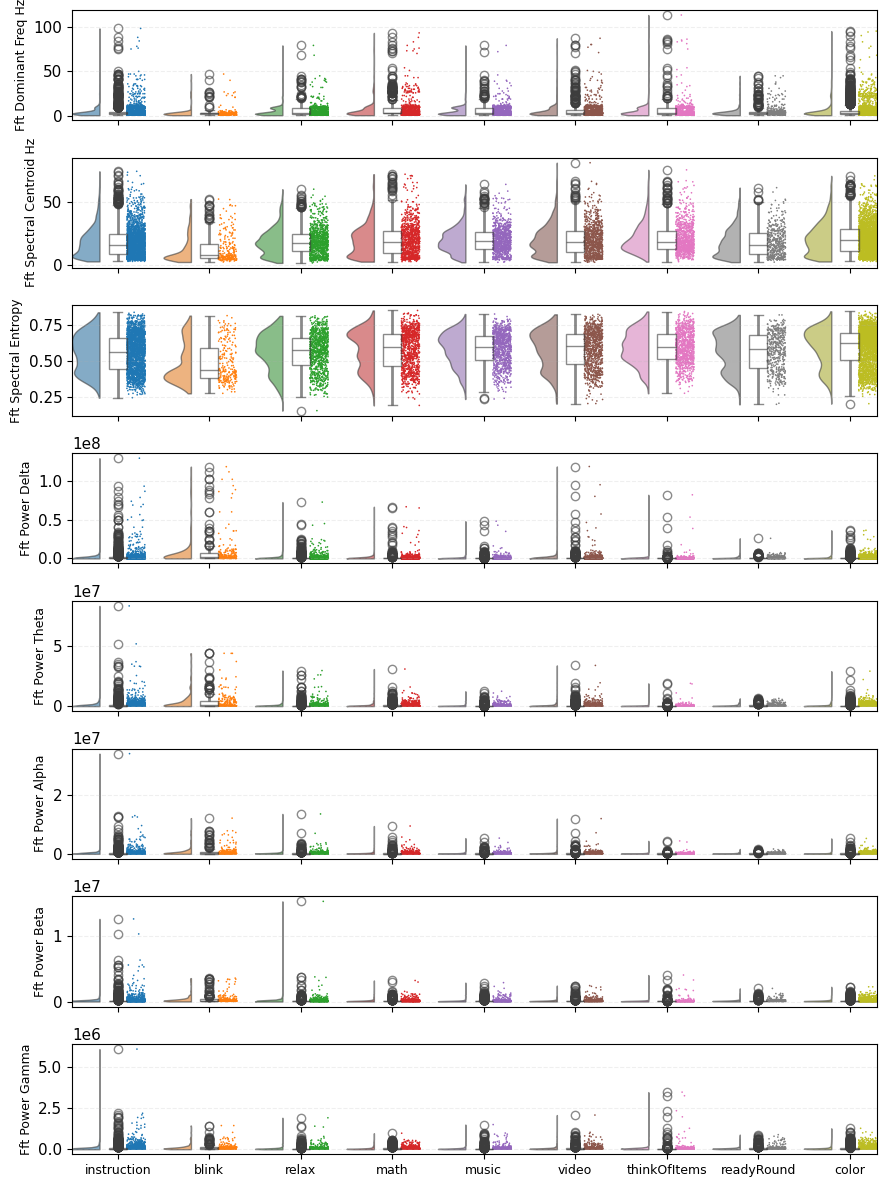

In [55]:
plot_distribution(data=eeg_data, ncols=1, collection='FFT')

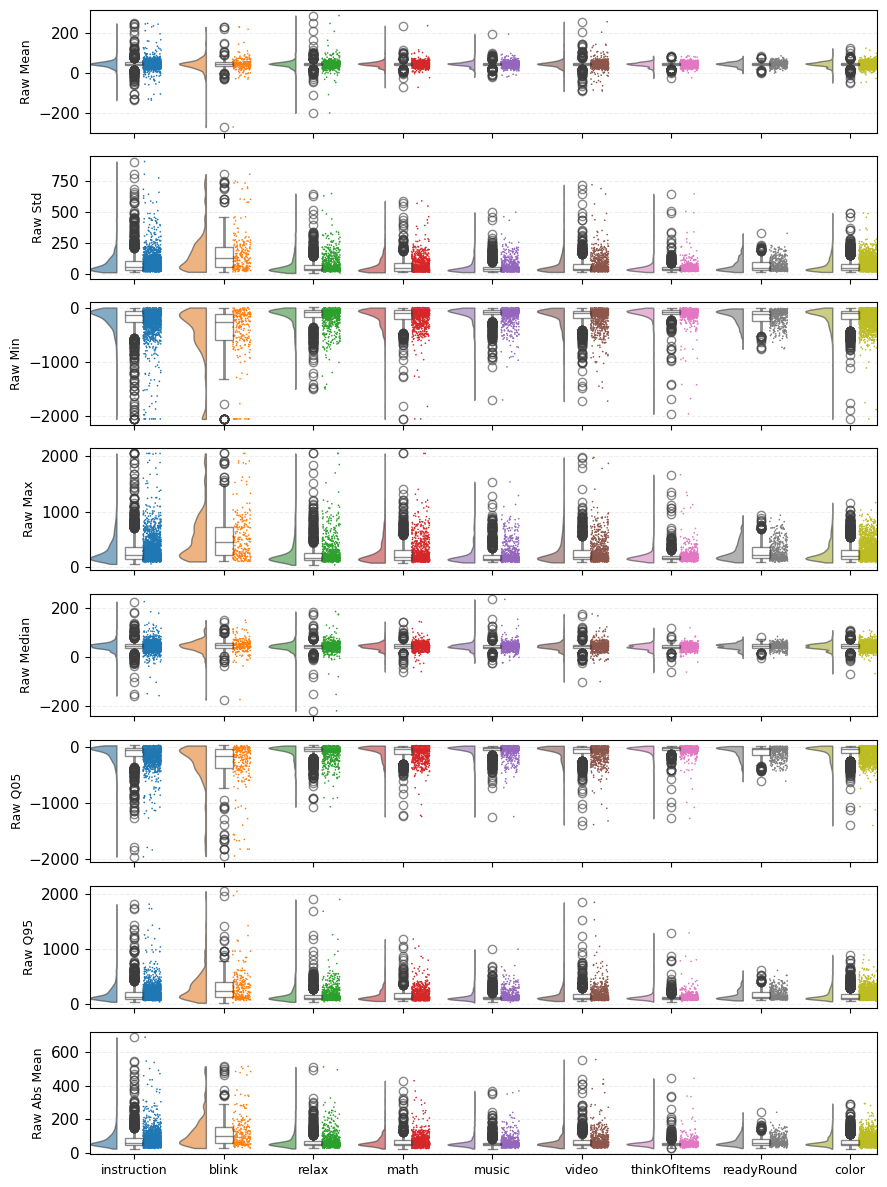

In [56]:
plot_distribution(data=eeg_data, ncols=1, collection='RAW')

In [57]:
eeg_data['label'].unique()

array(['instruction', 'blink', 'relax', 'math', 'music', 'video',
       'thinkOfItems', 'readyRound', 'color'], dtype=object)

In [44]:
# feature_cols =  ['label'] + fft_columns # + POWER_BANDS + list(raw_features.keys())[1:-1]
# sns.pairplot(data=eeg_data[feature_cols], hue='label', diag_kind='kde', plot_kws={'alpha':0.75, 's':20})
# plt.suptitle('Raw Stats vs Power Bands Scatter Matrix', y=1.01)
# plt.tight_layout()
# plt.savefig('scatter_matrix_raw_vs_power_bands.pdf', bbox_inches='tight', dpi=300, transparent=True, facecolor='white', format='pdf')
# plt.show()
# plt.close()

## Normalizing the class imbalanceness

### Method 1. Simply assigning the 1-complement proportion of each class (naive method).

### Method 2. Normalizing the class weights from Mehotd 1 with (C - 1), where C is the number of classes.

### Method 3: Normlized inverse of class proportions (reverse distribution sould be observed!).


Mean of complementary: 0.8889 	 STD of complementary: 0.0721
Mean of normalized   : 0.1111 	 STD of normalized   : 0.0090


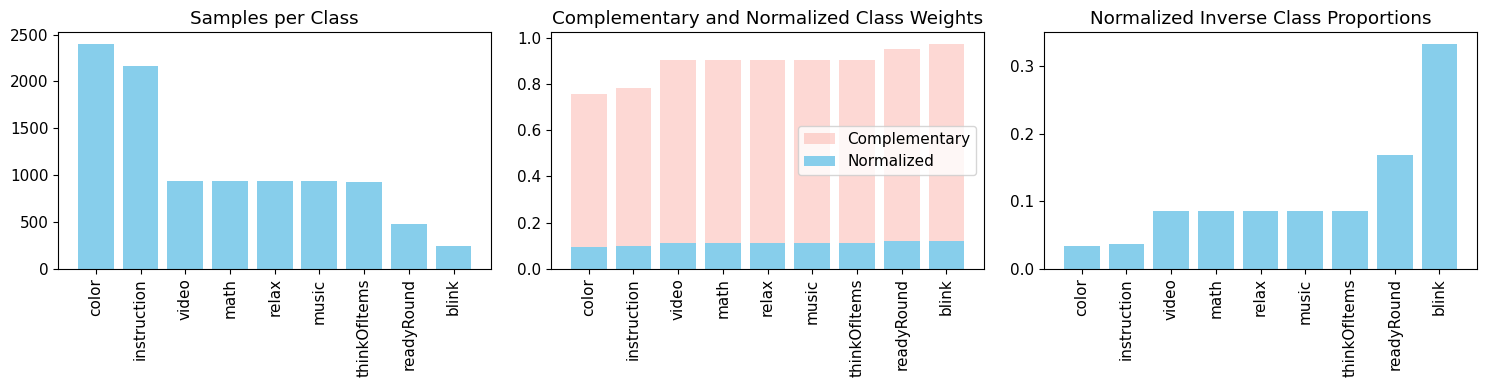

In [60]:
num_classes = len(eeg_data['label'].unique())
# print(f"Number of unique classes: {num_classes}")
sample_per_class = eeg_data['label'].value_counts()
class_proportions = eeg_data['label'].value_counts(normalize=True)

# Method 1: class weight = 1 - class proportion 
complementary_class_weights = (1.0 - class_proportions)

# Method 2: class weight = (1 - class proportion) / (num_classes - 1)
normalized_class_weights = complementary_class_weights / (num_classes - 1)

print(f'Mean of complementary: {complementary_class_weights.mean():.4f} \t STD of complementary: {complementary_class_weights.std():.4f}')
print(f'Mean of normalized   : {normalized_class_weights.mean():.4f} \t STD of normalized   : {normalized_class_weights.std():.4f}')

# Method 3: class weight = 1 / class proportion
normalized_inverse_proportions = 1.0 / (class_proportions + 1e-8)
normalized_inverse_proportions = normalized_inverse_proportions / normalized_inverse_proportions.sum()

# print("Class proportions:\n", class_proportions)
# print("Class weights:\n", normalized_class_weights)

fig, axs = plt.subplots(1, 3, figsize=(15, 4))

axs[0].bar(sample_per_class.index, sample_per_class.values, color='skyblue')
axs[0].set_title('Samples per Class')
axs[0].set_xticks(ticks=range(len(sample_per_class.index)))
axs[0].set_xticklabels(labels=sample_per_class.index, rotation=90)

axs[1].bar(complementary_class_weights.index, complementary_class_weights.values, color='salmon', alpha=0.3, label='Complementary')
axs[1].bar(normalized_class_weights.index, normalized_class_weights.values, color='skyblue', label='Normalized')
axs[1].set_title('Complementary and Normalized Class Weights')
axs[1].set_xticks(ticks=range(len(normalized_class_weights.index)))
axs[1].set_xticklabels(labels=normalized_class_weights.index, rotation=90)
axs[1].legend(loc='right')

axs[2].bar(normalized_inverse_proportions.index, normalized_inverse_proportions.values, color='skyblue')
axs[2].set_title('Normalized Inverse Class Proportions')
axs[2].set_xticks(ticks=range(len(normalized_inverse_proportions.index)))
axs[2].set_xticklabels(labels=normalized_inverse_proportions.index, rotation=90)

plt.tight_layout()
plt.show()

# An MLP model for classification


In [81]:
# Device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# Extract features (8 power bands) and target (class label)
# X = np.array(eeg_data['eeg_power'].tolist(), dtype=np.float32)
X = eeg_data[POWER_BANDS + fft_feature_cols + list(raw_features.keys())[1:-1]].values.astype(np.float32)
y = eeg_data['label'].values
subject_ids = eeg_data['id'].values

# Encode class labels to numeric values
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)
num_classes = len(label_encoder.classes_)

print(f"Feature shape: {X.shape}")
print(f"Number of classes: {num_classes}")
print(f"Class labels: {label_encoder.classes_}")
print(f"Total unique subjects: {len(np.unique(subject_ids))}")

# Train-val split per subject (80/20, no leakage) → 24 train / 6 val subjects
gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
train_idx, val_idx = next(gss.split(X, y_encoded, groups=subject_ids))

X_train, X_val = X[train_idx], X[val_idx]
y_train, y_val = y_encoded[train_idx], y_encoded[val_idx]
subjects_train = np.unique(subject_ids[train_idx])
subjects_val   = np.unique(subject_ids[val_idx])

print(f"\nTrain-Val split (per subject, no leakage):")
print(f"  Train: {len(subjects_train)} subjects  ({len(train_idx)} rows)")
print(f"  Val:   {len(subjects_val)} subjects  ({len(val_idx)} rows)")

# Complementary class weights from training set only
class_weights = torch.tensor(
    [1.0 - float((y_train == i).sum()) / len(y_train) for i in range(num_classes)],
    dtype=torch.float32
)
class_weights = (class_weights / class_weights.sum() * num_classes).to(device)

print(f"\nComplementary Class Weights:")
for i, lbl in enumerate(label_encoder.classes_):
    print(f"  {lbl}: {class_weights[i].item():.4f}")

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)   # fit on train only
X_val   = scaler.transform(X_val)         # apply same transform to val

# Tensors (kept on CPU; DataLoader handles batching)
X_train_t = torch.tensor(X_train, dtype=torch.float32)
y_train_t = torch.tensor(y_train, dtype=torch.long)
X_val_t   = torch.tensor(X_val,   dtype=torch.float32)
y_val_t   = torch.tensor(y_val,   dtype=torch.long)

# MLP model
class EEGClassifier(nn.Module):
    def __init__(self, input_size, hidden_size1, hidden_size2, num_classes):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_size, hidden_size1), nn.ReLU(), nn.Dropout(0.45),
            nn.Linear(hidden_size1, hidden_size2), nn.ReLU(), nn.Dropout(0.45),
            nn.Linear(hidden_size2, num_classes)
        )
    def forward(self, x):
        return self.net(x)

model     = EEGClassifier(24, 32, 16, num_classes).to(device)
criterion = nn.CrossEntropyLoss(weight=class_weights, label_smoothing=0.05)
optimizer = optim.Adam(model.parameters(), lr=0.001, weight_decay=1e-3)

batch_size   = 32
train_loader = DataLoader(TensorDataset(X_train_t, y_train_t), batch_size=batch_size, shuffle=True)
val_loader   = DataLoader(TensorDataset(X_val_t,   y_val_t),   batch_size=batch_size, shuffle=False)

print(f"Device: {device}")
print(f"Train batches: {len(train_loader)} | Val batches: {len(val_loader)}")    


Feature shape: (9954, 24)
Number of classes: 9
Class labels: ['blink' 'color' 'instruction' 'math' 'music' 'readyRound' 'relax'
 'thinkOfItems' 'video']
Total unique subjects: 30

Train-Val split (per subject, no leakage):
  Train: 24 subjects  (8032 rows)
  Val:   6 subjects  (1922 rows)

Complementary Class Weights:
  blink: 1.0981
  color: 0.8533
  instruction: 0.8797
  math: 1.0191
  music: 1.0198
  readyRound: 1.0715
  relax: 1.0194
  thinkOfItems: 1.0202
  video: 1.0188
Device: cuda
Train batches: 251 | Val batches: 61


In [82]:
print(f"\nModel:\n{model}")


Model:
EEGClassifier(
  (net): Sequential(
    (0): Linear(in_features=24, out_features=32, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.45, inplace=False)
    (3): Linear(in_features=32, out_features=16, bias=True)
    (4): ReLU()
    (5): Dropout(p=0.45, inplace=False)
    (6): Linear(in_features=16, out_features=9, bias=True)
  )
)


## Diagnostics: class distribution per split & sklearn baselines


Class distribution (train vs val):
              train  val
blink           192   47
color          1940  465
instruction    1751  417
math            756  180
music           751  181
readyRound      382   90
relax           754  180
thinkOfItems    748  182
video           758  180

Majority-class baseline  Val F1-macro: 0.0433
Random Forest            Val F1-macro: 0.1112
Gradient Boosting        Val F1-macro: 0.1208

Classification Report — Gradient Boosting (Val):
              precision    recall  f1-score   support

       blink       0.00      0.00      0.00        47
       color       0.35      0.48      0.41       465
 instruction       0.25      0.60      0.36       417
        math       0.19      0.04      0.06       180
       music       0.17      0.02      0.04       181
  readyRound       0.00      0.00      0.00        90
       relax       0.18      0.08      0.11       180
thinkOfItems       0.12      0.03      0.04       182
       video       0.13      0.04      

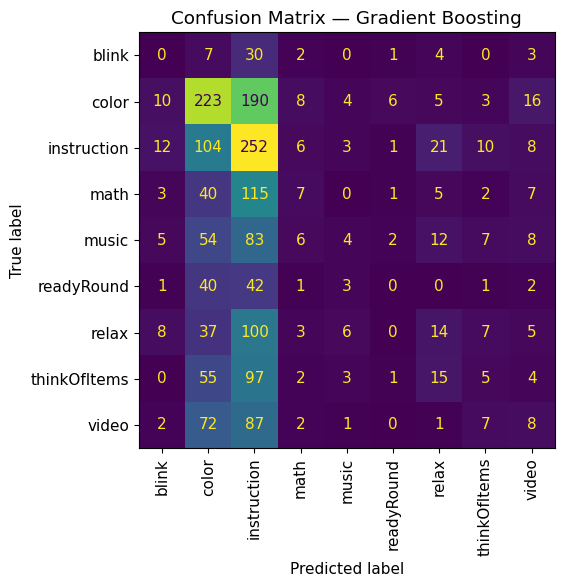

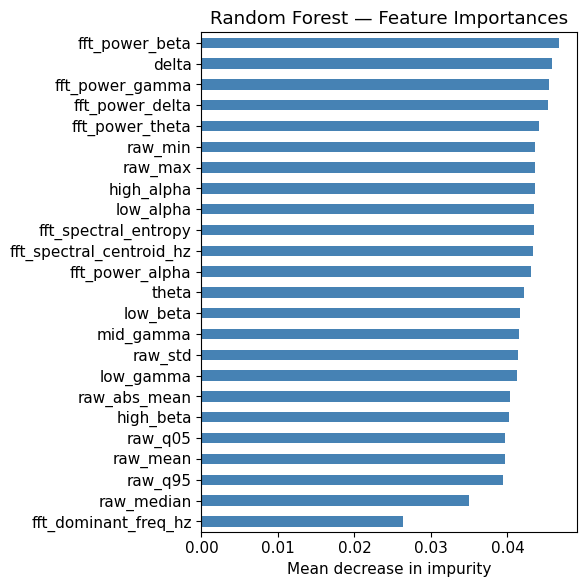

In [83]:
from sklearn.metrics import f1_score, classification_report, ConfusionMatrixDisplay
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

# ── Class distribution: train vs val ─────────────────────────────
train_labels = label_encoder.inverse_transform(y_train)
val_labels   = label_encoder.inverse_transform(y_val)

train_dist = pd.Series(train_labels).value_counts().sort_index()
val_dist   = pd.Series(val_labels).value_counts().sort_index()

dist_df = pd.DataFrame({'train': train_dist, 'val': val_dist}).fillna(0).astype(int)
print("Class distribution (train vs val):")
print(dist_df.to_string())
missing_in_val = [c for c in label_encoder.classes_ if c not in val_labels]
if missing_in_val:
    print(f"\nClasses absent from val set: {missing_in_val}")
    print("   F1-macro will be penalised for these — consider GroupKFold for stable evaluation.")

# ── Majority-class baseline ───────────────────────────────────────
majority = pd.Series(y_train).value_counts().idxmax()
majority_preds = np.full(len(y_val), majority)
print(f"\nMajority-class baseline  Val F1-macro: {f1_score(y_val, majority_preds, average='macro', zero_division=0):.4f}")

# ── Random Forest ─────────────────────────────────────────────────
rf = RandomForestClassifier(n_estimators=300, max_depth=None, class_weight='balanced',
                            random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)
rf_preds = rf.predict(X_val)
rf_f1 = f1_score(y_val, rf_preds, average='macro', zero_division=0)
print(f"Random Forest            Val F1-macro: {rf_f1:.4f}")

# ── Gradient Boosting ─────────────────────────────────────────────
gb = GradientBoostingClassifier(n_estimators=200, max_depth=4, learning_rate=0.05,
                                subsample=0.8, random_state=42)
gb.fit(X_train, y_train)
gb_preds = gb.predict(X_val)
gb_f1 = f1_score(y_val, gb_preds, average='macro', zero_division=0)
print(f"Gradient Boosting        Val F1-macro: {gb_f1:.4f}")

# ── Best baseline: full report + confusion matrix ─────────────────
best_preds, best_name = (rf_preds, "Random Forest") if rf_f1 >= gb_f1 else (gb_preds, "Gradient Boosting")
print(f"\nClassification Report — {best_name} (Val):")
print(classification_report(y_val, best_preds, target_names=label_encoder.classes_, zero_division=0))

fig, ax = plt.subplots(figsize=(8, 6))
ConfusionMatrixDisplay.from_predictions(
    y_val, best_preds,
    display_labels=label_encoder.classes_,
    xticks_rotation=90,
    ax=ax,
    colorbar=False
)
ax.set_title(f"Confusion Matrix — {best_name}")
plt.tight_layout()
plt.show()

# ── Feature importance (Random Forest) ───────────────────────────
fig, ax = plt.subplots(figsize=(6, 6))
importances = pd.Series(rf.feature_importances_, index=POWER_BANDS+fft_feature_cols+list(raw_features.keys())[1:-1]).sort_values()
importances.plot.barh(ax=ax, color='steelblue')
ax.set_title("Random Forest — Feature Importances")
ax.set_xlabel("Mean decrease in impurity")
plt.tight_layout()
plt.show()

# LightGBM — GroupKFold Cross-Validation (subject-leakage-free)


In [71]:
import lightgbm as lgb
from sklearn.model_selection import GroupKFold
from sklearn.metrics import f1_score, classification_report, ConfusionMatrixDisplay
from sklearn.preprocessing import LabelEncoder
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore', category=UserWarning)

FEATURE_COLS = POWER_BANDS + fft_feature_cols + list(raw_features.keys())[1:-1]

X_all = eeg_data[FEATURE_COLS].values.astype(np.float32)
y_all = eeg_data['label'].values
groups_all = eeg_data['id'].values

le = LabelEncoder()
y_enc = le.fit_transform(y_all)
n_classes = len(le.classes_)

# ── GroupKFold: 5 folds, no subject leakage ────────────────────────
N_SPLITS = 5
gkf = GroupKFold(n_splits=N_SPLITS)

fold_f1s, fold_reports, fold_cms = [], [], []
oof_preds  = np.full(len(y_enc), -1, dtype=int)
oof_true   = y_enc.copy()

for fold, (tr_idx, va_idx) in enumerate(gkf.split(X_all, y_enc, groups=groups_all), 1):
    X_tr, X_va = X_all[tr_idx], X_all[va_idx]
    y_tr, y_va = y_enc[tr_idx], y_enc[va_idx]

    # Class weights: inverse frequency on training fold
    counts = np.bincount(y_tr, minlength=n_classes).astype(float)
    sample_weight = (1.0 / np.maximum(counts[y_tr], 1)) * len(y_tr) / n_classes

    clf = lgb.LGBMClassifier(
        n_estimators=500,
        learning_rate=0.05,
        num_leaves=63,
        max_depth=-1,
        min_child_samples=10,
        subsample=0.8,
        colsample_bytree=0.8,
        class_weight='balanced',
        random_state=42,
        n_jobs=-1,
        verbose=-1,
    )
    clf.fit(
        X_tr, y_tr,
        sample_weight=sample_weight,
        eval_set=[(X_va, y_va)],
        callbacks=[lgb.early_stopping(50, verbose=False), lgb.log_evaluation(period=-1)],
    )

    preds = clf.predict(X_va)
    oof_preds[va_idx] = preds

    f1 = f1_score(y_va, preds, average='macro', zero_division=0)
    fold_f1s.append(f1)
    fold_reports.append(classification_report(y_va, preds, target_names=le.classes_, zero_division=0, output_dict=True))
    print(f"  Fold {fold}/{N_SPLITS} | subjects in val: {len(np.unique(groups_all[va_idx]))} | F1-macro: {f1:.4f}")

print(f"\nGroupKFold CV F1-macro:  {np.mean(fold_f1s):.4f} ± {np.std(fold_f1s):.4f}")
print(f"Per-fold:  {[f'{v:.4f}' for v in fold_f1s]}")


  Fold 1/5 | subjects in val: 5 | F1-macro: 0.1859
  Fold 2/5 | subjects in val: 6 | F1-macro: 0.1696
  Fold 3/5 | subjects in val: 6 | F1-macro: 0.1710
  Fold 4/5 | subjects in val: 7 | F1-macro: 0.1372
  Fold 5/5 | subjects in val: 6 | F1-macro: 0.1801

GroupKFold CV F1-macro:  0.1688 ± 0.0169
Per-fold:  ['0.1859', '0.1696', '0.1710', '0.1372', '0.1801']


Out-of-Fold Classification Report (all 5 folds combined):
              precision    recall  f1-score   support

       blink       0.12      0.18      0.14       239
       color       0.37      0.26      0.30      2405
 instruction       0.26      0.18      0.21      2168
        math       0.16      0.17      0.16       936
       music       0.12      0.14      0.13       932
  readyRound       0.08      0.13      0.10       472
       relax       0.15      0.18      0.16       934
thinkOfItems       0.17      0.24      0.20       930
       video       0.10      0.12      0.11       938

    accuracy                           0.19      9954
   macro avg       0.17      0.18      0.17      9954
weighted avg       0.22      0.19      0.20      9954



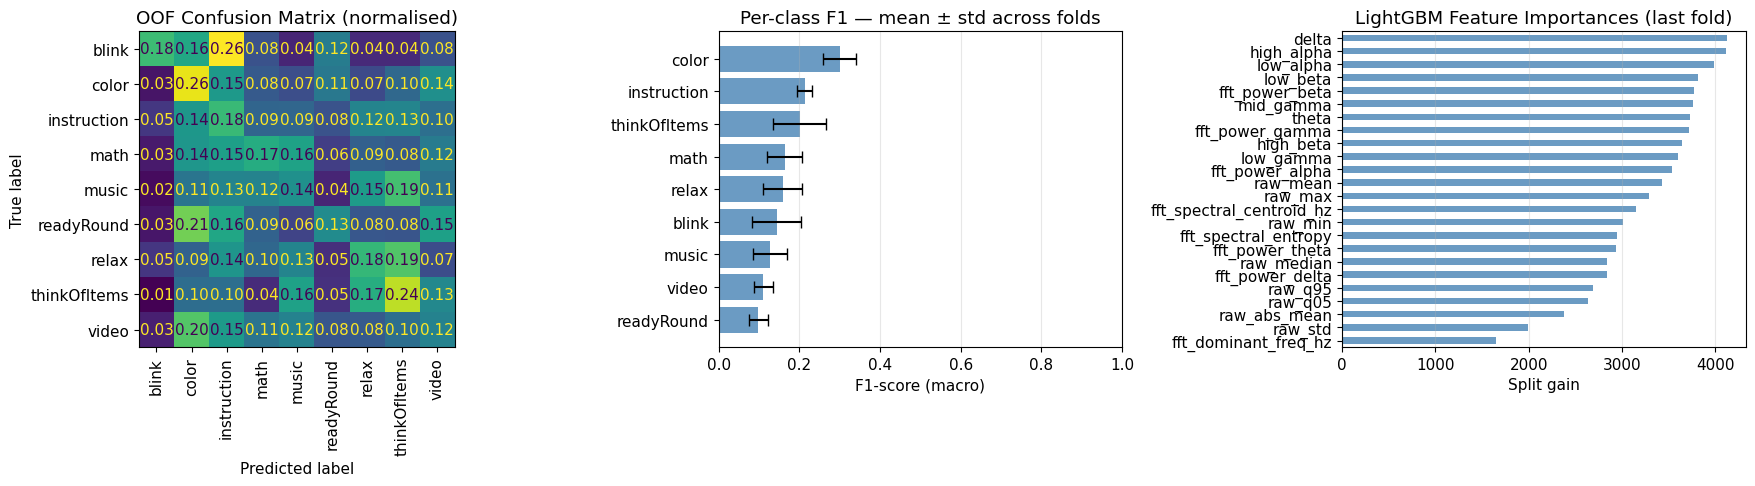

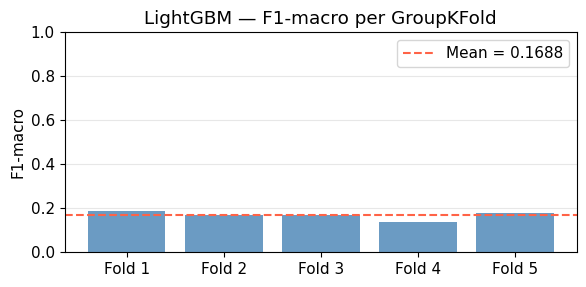

In [72]:
# ── OOF Classification Report ─────────────────────────────────────
print("Out-of-Fold Classification Report (all 5 folds combined):")
print(classification_report(oof_true, oof_preds, target_names=le.classes_, zero_division=0))

# ── Per-class F1 across folds ─────────────────────────────────────
per_class_f1 = {
    cls: [fold_reports[f][cls]['f1-score'] for f in range(N_SPLITS)]
    for cls in le.classes_
}
per_class_mean = {cls: np.mean(v) for cls, v in per_class_f1.items()}
per_class_std  = {cls: np.std(v)  for cls, v in per_class_f1.items()}

fig, axs = plt.subplots(1, 3, figsize=(18, 5))

# -- 1. OOF Confusion Matrix
ConfusionMatrixDisplay.from_predictions(
    oof_true, oof_preds,
    display_labels=le.classes_,
    xticks_rotation=90,
    ax=axs[0],
    colorbar=False,
    normalize='true',
    values_format='.2f',
)
axs[0].set_title('OOF Confusion Matrix (normalised)')

# -- 2. Per-class F1 mean ± std
sorted_cls = sorted(per_class_mean, key=lambda c: per_class_mean[c])
means = [per_class_mean[c] for c in sorted_cls]
stds  = [per_class_std[c]  for c in sorted_cls]
axs[1].barh(sorted_cls, means, xerr=stds, color='steelblue', alpha=0.8, capsize=4)
axs[1].set_xlabel('F1-score (macro)')
axs[1].set_title('Per-class F1 — mean ± std across folds')
axs[1].set_xlim(0, 1)
axs[1].grid(axis='x', alpha=0.3)

# -- 3. Feature importance (last fold model)
feat_imp = pd.Series(clf.feature_importances_, index=FEATURE_COLS).sort_values()
feat_imp.plot.barh(ax=axs[2], color='steelblue', alpha=0.8)
axs[2].set_title('LightGBM Feature Importances (last fold)')
axs[2].set_xlabel('Split gain')
axs[2].grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.show()

# -- 4. Fold-level F1 bar chart
fig2, ax2 = plt.subplots(figsize=(6, 3))
ax2.bar([f'Fold {i+1}' for i in range(N_SPLITS)], fold_f1s, color='steelblue', alpha=0.8)
ax2.axhline(np.mean(fold_f1s), color='tomato', linestyle='--', label=f'Mean = {np.mean(fold_f1s):.4f}')
ax2.set_ylim(0, 1)
ax2.set_ylabel('F1-macro')
ax2.set_title('LightGBM — F1-macro per GroupKFold')
ax2.legend()
ax2.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()


# Improving Classification: Per-Subject Normalization + Richer Features

**Problem:** Absolute EEG power varies enormously across individuals → subject-independent F1 ≈ 0.17.

**Fixes applied:**
1. **Per-subject z-score** — subtract each subject's mean and divide by std per feature (removes individual baseline)
2. **Band-power ratios** — theta/alpha, alpha/beta, delta/theta (subject-invariant relative measures)
3. **Hjorth parameters** — activity, mobility, complexity from raw signal (widely used in BCI)
4. **UMAP visualisation** — check class separability before and after normalization


In [73]:
import warnings
warnings.filterwarnings('ignore')

# ── 1. Hjorth parameters from raw signal ──────────────────────────
def hjorth_params(raw_signal):
    x = np.asarray(raw_signal, dtype=np.float64)
    if x is None or len(x) < 4:
        return np.nan, np.nan, np.nan
    activity = float(np.var(x))
    d1 = np.diff(x)
    mobility = float(np.sqrt(np.var(d1) / activity)) if activity > 0 else np.nan
    d2 = np.diff(d1)
    mob_d1 = np.sqrt(np.var(d2) / np.var(d1)) if np.var(d1) > 0 else np.nan
    complexity = float(mob_d1 / mobility) if (mobility and mobility > 0) else np.nan
    return activity, mobility, complexity

hjorth_cols = ['hjorth_activity', 'hjorth_mobility', 'hjorth_complexity']
for col in hjorth_cols:
    eeg_data.drop(columns=[col], inplace=True, errors='ignore')

hjorth_vals = eeg_data['raw_values'].apply(
    lambda x: hjorth_params(x) if x is not None else (np.nan, np.nan, np.nan)
)
eeg_data[hjorth_cols] = pd.DataFrame(hjorth_vals.tolist(), index=eeg_data.index)

# ── 2. Band-power ratios (subject-invariant relative measures) ─────
eps = 1e-8
eeg_data['ratio_theta_alpha']  = eeg_data['theta']     / (eeg_data['low_alpha'] + eeg_data['high_alpha'] + eps)
eeg_data['ratio_alpha_beta']   = (eeg_data['low_alpha'] + eeg_data['high_alpha']) / (eeg_data['low_beta'] + eeg_data['high_beta'] + eps)
eeg_data['ratio_delta_theta']  = eeg_data['delta']     / (eeg_data['theta'] + eps)
eeg_data['ratio_beta_alpha']   = (eeg_data['low_beta']  + eeg_data['high_beta'])  / (eeg_data['low_alpha'] + eeg_data['high_alpha'] + eps)
eeg_data['ratio_gamma_beta']   = (eeg_data['low_gamma'] + eeg_data['mid_gamma'])  / (eeg_data['low_beta']  + eeg_data['high_beta'] + eps)
ratio_cols = ['ratio_theta_alpha', 'ratio_alpha_beta', 'ratio_delta_theta', 'ratio_beta_alpha', 'ratio_gamma_beta']

# ── 3. Extended feature set ────────────────────────────────────────
FEATURE_COLS_V2 = (
    POWER_BANDS
    + fft_feature_cols
    + list(raw_features.keys())[1:-1]
    + hjorth_cols
    + ratio_cols
)
print(f"Total features v2: {len(FEATURE_COLS_V2)}")
print(FEATURE_COLS_V2)


Total features v2: 32
['delta', 'theta', 'low_alpha', 'high_alpha', 'low_beta', 'high_beta', 'low_gamma', 'mid_gamma', 'fft_dominant_freq_hz', 'fft_spectral_centroid_hz', 'fft_spectral_entropy', 'fft_power_delta', 'fft_power_theta', 'fft_power_alpha', 'fft_power_beta', 'fft_power_gamma', 'raw_mean', 'raw_std', 'raw_min', 'raw_max', 'raw_median', 'raw_q05', 'raw_q95', 'raw_abs_mean', 'hjorth_activity', 'hjorth_mobility', 'hjorth_complexity', 'ratio_theta_alpha', 'ratio_alpha_beta', 'ratio_delta_theta', 'ratio_beta_alpha', 'ratio_gamma_beta']


In [74]:
# ── 4. Per-subject z-score normalisation ──────────────────────────
# For each feature, within each subject: subtract mean, divide by std.
# This removes inter-subject baseline differences — the #1 cause of poor
# subject-independent generalisation.

df_norm = eeg_data[['id'] + FEATURE_COLS_V2 + ['label']].copy()

for feat in FEATURE_COLS_V2:
    subj_mean = df_norm.groupby('id')[feat].transform('mean')
    subj_std  = df_norm.groupby('id')[feat].transform('std').replace(0, 1)
    df_norm[feat] = (df_norm[feat] - subj_mean) / subj_std

# Clip extreme outliers post-normalisation (±5σ)
for feat in FEATURE_COLS_V2:
    df_norm[feat] = df_norm[feat].clip(-5, 5)

# Drop rows with any NaN (subjects with only 1 sample for a label get std=NaN)
df_norm = df_norm.dropna(subset=FEATURE_COLS_V2)
print(f"Rows after dropping NaN: {len(df_norm)}  (dropped {len(eeg_data) - len(df_norm)})")

X_v2     = df_norm[FEATURE_COLS_V2].values.astype(np.float32)
y_v2     = le.transform(df_norm['label'].values)
groups_v2 = df_norm['id'].values

print(f"Feature matrix: {X_v2.shape}  |  Classes: {len(np.unique(y_v2))}")


Rows after dropping NaN: 9954  (dropped 0)
Feature matrix: (9954, 32)  |  Classes: 9


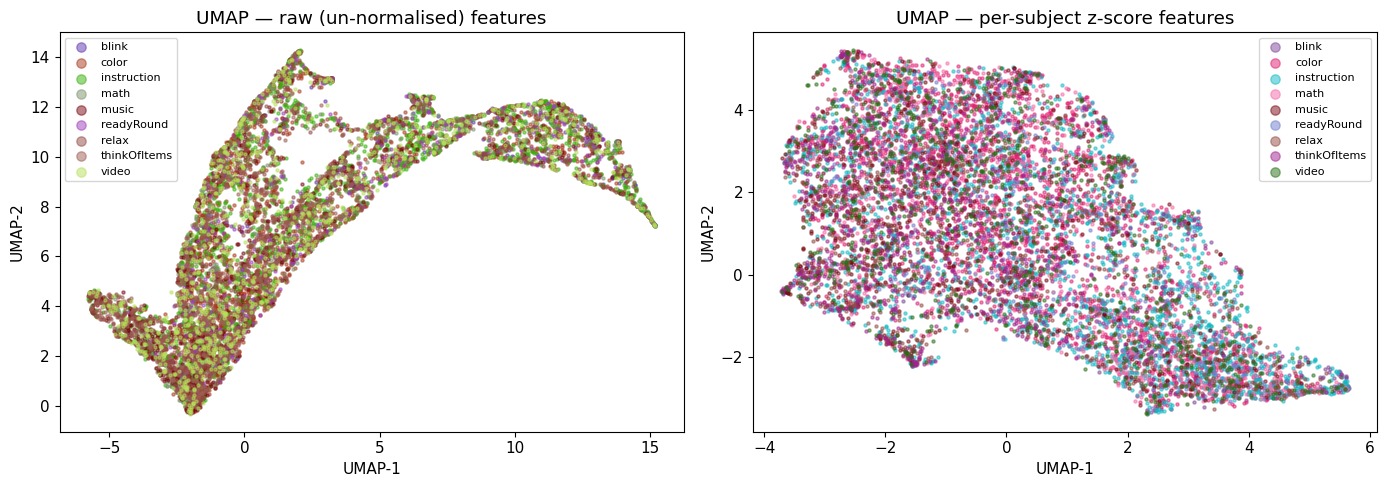

In [78]:
# ── 5. UMAP: visualise class separability ─────────────────────────
try:
    from umap import UMAP
    reducer = UMAP(n_components=2, random_state=42, n_neighbors=30, min_dist=0.1, metric='euclidean')
    emb = reducer.fit_transform(X_v2)

    fig, axs = plt.subplots(1, 2, figsize=(14, 5))
    for ax, title, X_plot in zip(axs,
            ['UMAP — raw (un-normalised) features', 'UMAP — per-subject z-score features'],
            [eeg_data.loc[df_norm.index, FEATURE_COLS_V2].values, X_v2]):

        emb_plot = UMAP(n_components=2, random_state=42, n_neighbors=30, min_dist=0.1).fit_transform(X_plot)
        classes_plot = df_norm['label'].values
        palette = {c: color_map.get(c, np.random.rand(3,)) for c in np.unique(classes_plot)}
        for cls in np.unique(classes_plot):
            mask = classes_plot == cls
            ax.scatter(emb_plot[mask, 0], emb_plot[mask, 1],
                        c=[palette[cls]], label=cls, s=5, alpha=0.5)
        ax.set_title(title)
        ax.legend(markerscale=3, fontsize=8, loc='best')
        ax.set_xlabel('UMAP-1')
        ax.set_ylabel('UMAP-2')
    plt.tight_layout()
    plt.show()

except ImportError:
    print("umap-learn not installed — run: pip install umap-learn")
    print("Skipping UMAP visualisation.")


In [79]:
# ── 6. LightGBM GroupKFold on normalised + enriched features ──────
import lightgbm as lgb
from sklearn.model_selection import GroupKFold
from sklearn.metrics import f1_score, classification_report, ConfusionMatrixDisplay

N_SPLITS = 5
gkf = GroupKFold(n_splits=N_SPLITS)

fold_f1s_v2, fold_reports_v2 = [], []
oof_preds_v2 = np.full(len(y_v2), -1, dtype=int)

for fold, (tr_idx, va_idx) in enumerate(gkf.split(X_v2, y_v2, groups=groups_v2), 1):
    X_tr, X_va = X_v2[tr_idx], X_v2[va_idx]
    y_tr, y_va = y_v2[tr_idx], y_v2[va_idx]

    counts = np.bincount(y_tr, minlength=n_classes).astype(float)
    sample_weight = (1.0 / np.maximum(counts[y_tr], 1)) * len(y_tr) / n_classes

    clf_v2 = lgb.LGBMClassifier(
        n_estimators=800,
        learning_rate=0.03,
        num_leaves=63,
        max_depth=-1,
        min_child_samples=10,
        subsample=0.8,
        colsample_bytree=0.8,
        reg_alpha=0.1,
        reg_lambda=0.1,
        class_weight='balanced',
        random_state=42,
        n_jobs=-1,
        verbose=-1,
    )
    clf_v2.fit(
        X_tr, y_tr,
        sample_weight=sample_weight,
        eval_set=[(X_va, y_va)],
        callbacks=[lgb.early_stopping(60, verbose=False), lgb.log_evaluation(period=-1)],
    )

    preds_v2 = clf_v2.predict(X_va)
    oof_preds_v2[va_idx] = preds_v2

    f1_v2 = f1_score(y_va, preds_v2, average='macro', zero_division=0)
    fold_f1s_v2.append(f1_v2)
    fold_reports_v2.append(classification_report(y_va, preds_v2, target_names=le.classes_, zero_division=0, output_dict=True))
    print(f"  Fold {fold}/{N_SPLITS} | subjects: {len(np.unique(groups_v2[va_idx]))} | F1-macro: {f1_v2:.4f}  (prev: {fold_f1s[fold-1]:.4f})")

print(f"\nGroupKFold CV F1-macro (v2):  {np.mean(fold_f1s_v2):.4f} ± {np.std(fold_f1s_v2):.4f}")
print(f"GroupKFold CV F1-macro (v1):  {np.mean(fold_f1s):.4f} ± {np.std(fold_f1s):.4f}")
print(f"Delta: {np.mean(fold_f1s_v2) - np.mean(fold_f1s):+.4f}")


  Fold 1/5 | subjects: 5 | F1-macro: 0.2033  (prev: 0.1859)
  Fold 2/5 | subjects: 6 | F1-macro: 0.1769  (prev: 0.1696)
  Fold 3/5 | subjects: 6 | F1-macro: 0.1680  (prev: 0.1710)
  Fold 4/5 | subjects: 7 | F1-macro: 0.1521  (prev: 0.1372)
  Fold 5/5 | subjects: 6 | F1-macro: 0.1937  (prev: 0.1801)

GroupKFold CV F1-macro (v2):  0.1788 ± 0.0182
GroupKFold CV F1-macro (v1):  0.1688 ± 0.0169
Delta: +0.0100


OOF Classification Report (per-subject normalised, enriched features):
              precision    recall  f1-score   support

       blink       0.20      0.20      0.20       239
       color       0.37      0.32      0.35      2405
 instruction       0.30      0.22      0.25      2168
        math       0.13      0.15      0.14       936
       music       0.16      0.22      0.19       932
  readyRound       0.09      0.12      0.10       472
       relax       0.14      0.15      0.14       934
thinkOfItems       0.15      0.15      0.15       930
       video       0.09      0.09      0.09       938

    accuracy                           0.21      9954
   macro avg       0.18      0.18      0.18      9954
weighted avg       0.23      0.21      0.21      9954



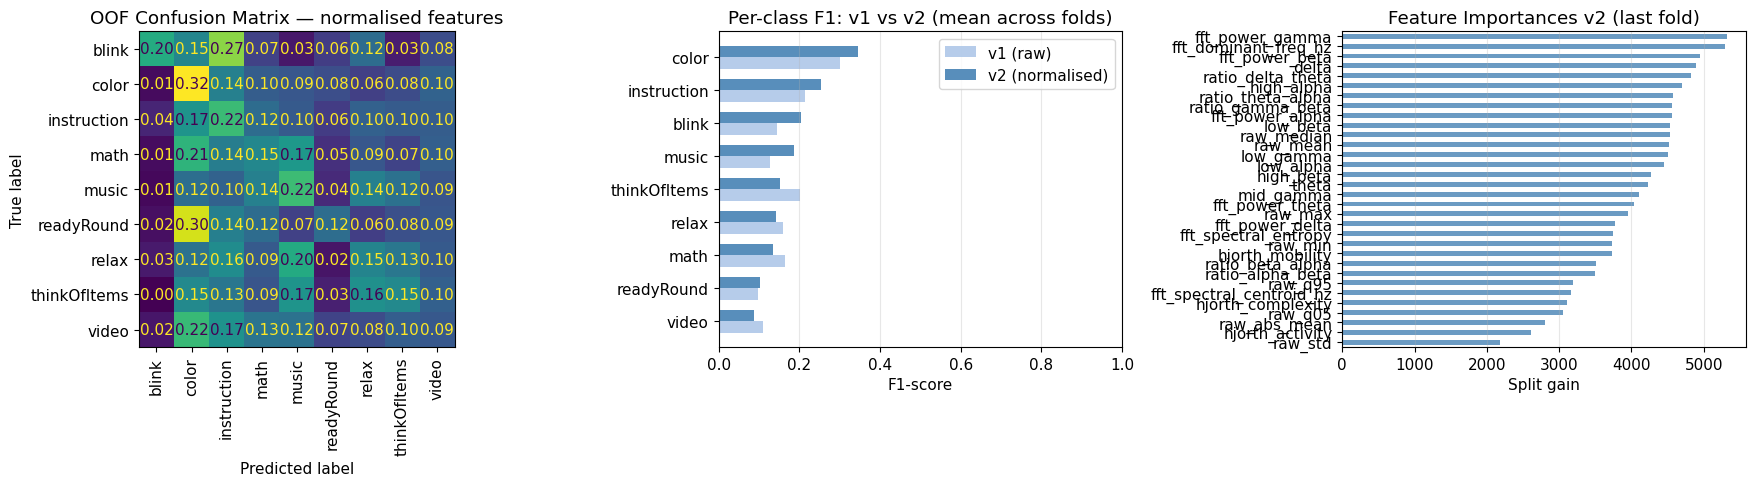

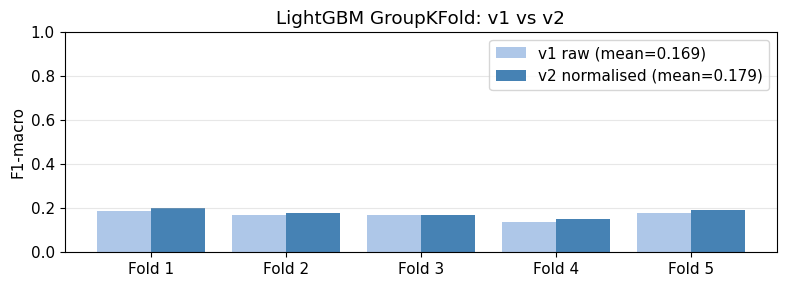

In [80]:
# ── 7. Results: comparison + OOF report + confusion matrix ────────
per_class_f1_v2 = {
    cls: [fold_reports_v2[f][cls]['f1-score'] for f in range(N_SPLITS)]
    for cls in le.classes_
}
per_class_mean_v2 = {cls: np.mean(v) for cls, v in per_class_f1_v2.items()}
per_class_std_v2  = {cls: np.std(v)  for cls, v in per_class_f1_v2.items()}

print("OOF Classification Report (per-subject normalised, enriched features):")
print(classification_report(y_v2, oof_preds_v2, target_names=le.classes_, zero_division=0))

fig, axs = plt.subplots(1, 3, figsize=(18, 5))

# Confusion matrix
ConfusionMatrixDisplay.from_predictions(
    y_v2, oof_preds_v2,
    display_labels=le.classes_,
    xticks_rotation=90,
    ax=axs[0],
    colorbar=False,
    normalize='true',
    values_format='.2f',
)
axs[0].set_title('OOF Confusion Matrix — normalised features')

# Per-class F1 comparison: v1 vs v2
sorted_cls = sorted(per_class_mean_v2, key=lambda c: per_class_mean_v2[c])
x = np.arange(len(sorted_cls))
w = 0.35
axs[1].barh(x - w/2, [per_class_mean[c]   for c in sorted_cls], w, label='v1 (raw)',        color='#aec7e8', alpha=0.9)
axs[1].barh(x + w/2, [per_class_mean_v2[c] for c in sorted_cls], w, label='v2 (normalised)', color='steelblue', alpha=0.9)
axs[1].set_yticks(x)
axs[1].set_yticklabels(sorted_cls)
axs[1].set_xlabel('F1-score')
axs[1].set_title('Per-class F1: v1 vs v2 (mean across folds)')
axs[1].set_xlim(0, 1)
axs[1].legend()
axs[1].grid(axis='x', alpha=0.3)

# Feature importance v2
feat_imp_v2 = pd.Series(clf_v2.feature_importances_, index=FEATURE_COLS_V2).sort_values()
feat_imp_v2.plot.barh(ax=axs[2], color='steelblue', alpha=0.8)
axs[2].set_title('Feature Importances v2 (last fold)')
axs[2].set_xlabel('Split gain')
axs[2].grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.show()

# Fold comparison bar chart
fig2, ax2 = plt.subplots(figsize=(8, 3))
x = np.arange(N_SPLITS)
ax2.bar(x - 0.2, fold_f1s,    0.4, label=f'v1 raw (mean={np.mean(fold_f1s):.3f})',        color='#aec7e8')
ax2.bar(x + 0.2, fold_f1s_v2, 0.4, label=f'v2 normalised (mean={np.mean(fold_f1s_v2):.3f})', color='steelblue')
ax2.set_xticks(x)
ax2.set_xticklabels([f'Fold {i+1}' for i in range(N_SPLITS)])
ax2.set_ylim(0, 1)
ax2.set_ylabel('F1-macro')
ax2.set_title('LightGBM GroupKFold: v1 vs v2')
ax2.legend()
ax2.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()


# Training loop


Epoch   1/80 | Train Loss: 2.1497  Train F1: 0.0809 | Val Loss: 2.0765  Val F1: 0.0813 | LR: 1.00e-03  <- best
Epoch   2/80 | Train Loss: 2.0943  Train F1: 0.0765 | Val Loss: 2.0569  Val F1: 0.0835 | LR: 1.00e-03  <- best
Epoch   4/80 | Train Loss: 2.0682  Train F1: 0.0864 | Val Loss: 2.0422  Val F1: 0.0848 | LR: 1.00e-03  <- best
Epoch   5/80 | Train Loss: 2.0542  Train F1: 0.0958 | Val Loss: 2.0392  Val F1: 0.0843 | LR: 1.00e-03
Epoch   6/80 | Train Loss: 2.0444  Train F1: 0.1027 | Val Loss: 2.0368  Val F1: 0.0850 | LR: 1.00e-03  <- best
Epoch   8/80 | Train Loss: 2.0385  Train F1: 0.0991 | Val Loss: 2.0331  Val F1: 0.0857 | LR: 1.00e-03  <- best
Epoch  10/80 | Train Loss: 2.0258  Train F1: 0.1016 | Val Loss: 2.0274  Val F1: 0.0828 | LR: 1.00e-03
Epoch  12/80 | Train Loss: 2.0237  Train F1: 0.1025 | Val Loss: 2.0311  Val F1: 0.1032 | LR: 1.00e-03  <- best
Epoch  15/80 | Train Loss: 2.0162  Train F1: 0.1080 | Val Loss: 2.0260  Val F1: 0.0852 | LR: 1.00e-03
Epoch  20/80 | Train Loss: 2

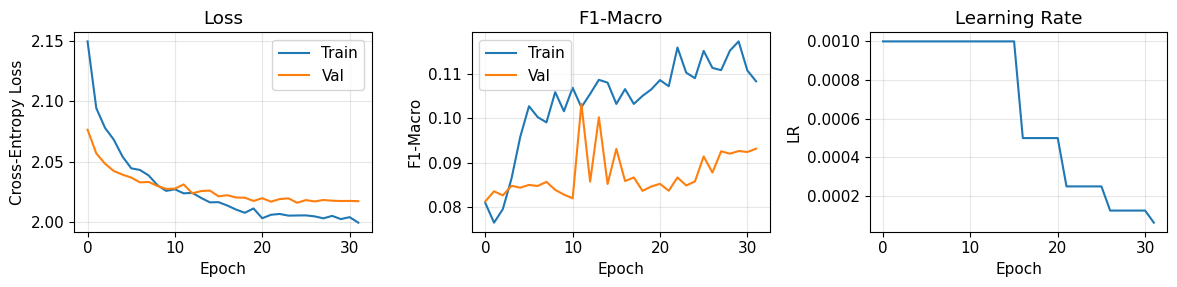

In [84]:
from sklearn.metrics import f1_score, classification_report

num_epochs = 80
best_f1 = -1.0
best_weights = None
best_epoch = 0
patience = 20
patience_counter = 0
min_delta = 1e-4

scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode='max',
    factor=0.5,
    patience=4,
    min_lr=1e-5
)

history = {
    'train_loss': [],
    'val_loss': [],
    'train_f1': [],
    'val_f1': [],
    'lr': []
}

for epoch in range(1, num_epochs + 1):
    # Training
    model.train()
    train_loss = 0.0
    train_preds, train_targets = [], []

    for xb, yb in train_loader:
        xb, yb = xb.to(device), yb.to(device)
        optimizer.zero_grad()
        logits = model(xb)
        loss = criterion(logits, yb)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()

        train_loss += loss.item() * len(yb)
        train_preds.extend(logits.argmax(dim=1).detach().cpu().numpy())
        train_targets.extend(yb.detach().cpu().numpy())

    train_loss /= len(y_train)
    train_f1 = f1_score(train_targets, train_preds, average='macro', zero_division=0)

    # Validation
    model.eval()
    val_loss = 0.0
    val_preds, val_targets = [], []

    with torch.no_grad():
        for xb, yb in val_loader:
            xb, yb = xb.to(device), yb.to(device)
            logits = model(xb)
            loss = criterion(logits, yb)
            val_loss += loss.item() * len(yb)
            val_preds.extend(logits.argmax(dim=1).cpu().numpy())
            val_targets.extend(yb.cpu().numpy())

    val_loss /= len(y_val)
    val_f1 = f1_score(val_targets, val_preds, average='macro', zero_division=0)

    scheduler.step(val_f1)
    current_lr = optimizer.param_groups[0]['lr']

    history['train_loss'].append(train_loss)
    history['val_loss'].append(val_loss)
    history['train_f1'].append(train_f1)
    history['val_f1'].append(val_f1)
    history['lr'].append(current_lr)

    improved = val_f1 > (best_f1 + min_delta)
    if improved:
        best_f1 = val_f1
        best_epoch = epoch
        best_weights = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
        patience_counter = 0
    else:
        patience_counter += 1

    if epoch % 5 == 0 or epoch == 1 or improved:
        print(
            f"Epoch {epoch:3d}/{num_epochs} | "
            f"Train Loss: {train_loss:.4f}  Train F1: {train_f1:.4f} | "
            f"Val Loss: {val_loss:.4f}  Val F1: {val_f1:.4f} | "
            f"LR: {current_lr:.2e}" + ("  <- best" if improved else "")
        )

    if patience_counter >= patience:
        print(f"\nEarly stopping at epoch {epoch} (best epoch: {best_epoch}, best val F1-macro: {best_f1:.4f})")
        break

if best_weights is None:
    best_weights = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}

model.load_state_dict({k: v.to(device) for k, v in best_weights.items()})
print(f"\nBest Val F1-macro: {best_f1:.4f} at epoch {best_epoch} (model restored)")

# Final report on validation set using best checkpoint
model.eval()
final_preds, final_targets = [], []
with torch.no_grad():
    for xb, yb in val_loader:
        xb = xb.to(device)
        logits = model(xb)
        final_preds.extend(logits.argmax(dim=1).cpu().numpy())
        final_targets.extend(yb.numpy())

final_val_f1 = f1_score(final_targets, final_preds, average='macro', zero_division=0)
print(f"Final Val F1-macro (best checkpoint): {final_val_f1:.4f}")

print("\nClassification Report (Validation Set):")
print(classification_report(
    final_targets,
    final_preds,
    target_names=label_encoder.classes_,
    zero_division=0
))

fig, axs = plt.subplots(1, 3, figsize=(12, 3))

axs[0].plot(history['train_loss'], label='Train')
axs[0].plot(history['val_loss'], label='Val')
axs[0].set_title('Loss')
axs[0].set_xlabel('Epoch')
axs[0].set_ylabel('Cross-Entropy Loss')
axs[0].legend()
axs[0].grid(alpha=0.3)

axs[1].plot(history['train_f1'], label='Train')
axs[1].plot(history['val_f1'], label='Val')
axs[1].set_title('F1-Macro')
axs[1].set_xlabel('Epoch')
axs[1].set_ylabel('F1-Macro')
axs[1].legend()
axs[1].grid(alpha=0.3)

axs[2].plot(history['lr'])
axs[2].set_title('Learning Rate')
axs[2].set_xlabel('Epoch')
axs[2].set_ylabel('LR')
axs[2].grid(alpha=0.3)

plt.tight_layout()
plt.show()

# IMAGINATION
### Matrisizng the features

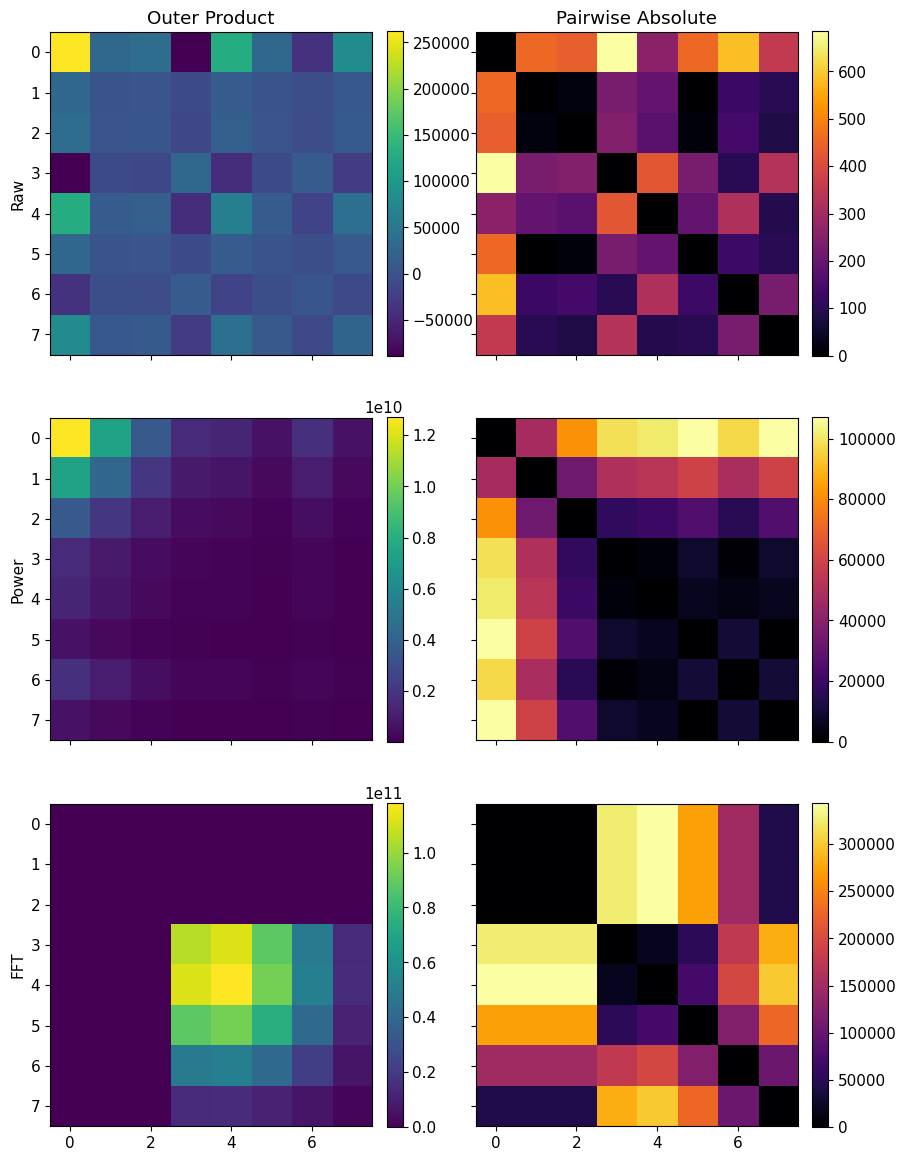

In [217]:
random_sample = eeg_data.iloc[np.random.choice(eeg_data.id)]

r = random_sample[list(raw_features.keys())].values.astype(float)
p = random_sample[POWER_BANDS].values.astype(float)
f = random_sample[fft_feature_cols].values.astype(float)

r_outer_matrix = np.outer(r, r)
r_dist_matrix = np.abs(r[:, None] - r[None, :])

p_outer_matrix = np.outer(p, p)
p_dist_matrix = np.abs(p[:, None] - p[None, :])

f_outer_matrix = np.outer(f, f)
f_dist_matrix = np.abs(f[:, None] - f[None, :])

fig, axs = plt.subplots(3, 2, figsize=(9, 12), sharex=True, sharey=True)

# RAW
im0 = axs[0, 0].imshow(r_outer_matrix, cmap='viridis')
axs[0, 0].set_title(f"Outer Product")
axs[0, 0].set_ylabel("Raw")
fig.colorbar(im0, ax=axs[0, 0], fraction=0.046, pad=0.04)
im1 = axs[0, 1].imshow(r_dist_matrix, cmap='inferno')
axs[0, 1].set_title("Pairwise Absolute")
fig.colorbar(im1, ax=axs[0, 1], fraction=0.046, pad=0.04)

# POWER
im0 = axs[1, 0].imshow(p_outer_matrix, cmap='viridis')
axs[1, 0].set_ylabel(f"Power")
fig.colorbar(im0, ax=axs[1, 0], fraction=0.046, pad=0.04)
im1 = axs[1, 1].imshow(p_dist_matrix, cmap='inferno')
fig.colorbar(im1, ax=axs[1, 1], fraction=0.046, pad=0.04)

# FFT
im0 = axs[2, 0].imshow(f_outer_matrix, cmap='viridis')
axs[2, 0].set_ylabel(f"FFT")
fig.colorbar(im0, ax=axs[2, 0], fraction=0.046, pad=0.04)
im1 = axs[2, 1].imshow(f_dist_matrix, cmap='inferno')
fig.colorbar(im1, ax=axs[2, 1], fraction=0.046, pad=0.04)

plt.tight_layout()
plt.show()

# CNN on 6-Matrix Image Tensors

Each sample is encoded as a **(6 × 8 × 8)** image:  
- channels 0–1: Raw-feature outer product & pairwise absolute difference  
- channels 2–3: Power-band outer product & pairwise absolute difference  
- channels 4–5: FFT-feature outer product & pairwise absolute difference  

Split is **subject-leakage-free** (GroupShuffleSplit, 80 / 20).  
Normalization is **per-channel**, computed on the training set only.

In [219]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import GroupShuffleSplit
from sklearn.metrics import f1_score, classification_report, ConfusionMatrixDisplay

# ── 1. Build (N, 6, 8, 8) matrix tensors — fully vectorized ──────
raw_cols = list(raw_features.keys())[1:-1] # 8 stat cols

R_feat = eeg_data[raw_cols].values.astype(np.float32)                  # (N, 8)
P_feat = eeg_data[POWER_BANDS].values.astype(np.float32)               # (N, 8)
F_feat = eeg_data[fft_feature_cols].values.astype(np.float32)          # (N, 8)

R_outer = np.einsum('ni,nj->nij', R_feat, R_feat)                      # (N,8,8)
R_dist  = np.abs(R_feat[:, :, None] - R_feat[:, None, :])
P_outer = np.einsum('ni,nj->nij', P_feat, P_feat)
P_dist  = np.abs(P_feat[:, :, None] - P_feat[:, None, :])
F_outer = np.einsum('ni,nj->nij', F_feat, F_feat)
F_dist  = np.abs(F_feat[:, :, None] - F_feat[:, None, :])

X_img = np.stack([R_outer, R_dist, P_outer, P_dist, F_outer, F_dist], axis=1)
print(f"Image tensor shape: {X_img.shape}")                            # (N, 6, 8, 8)

# ── 2. Encode labels + GroupShuffleSplit (80 % train / 20 % val) ──
y_img      = le.transform(eeg_data['label'].values)
groups_img = eeg_data['id'].values                                      # subject IDs

gss_img = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
tr_idx_img, va_idx_img = next(gss_img.split(X_img, y_img, groups=groups_img))

X_tr_img, X_va_img = X_img[tr_idx_img], X_img[va_idx_img]
y_tr_img, y_va_img = y_img[tr_idx_img], y_img[va_idx_img]

n_tr_subj = len(np.unique(groups_img[tr_idx_img]))
n_va_subj = len(np.unique(groups_img[va_idx_img]))
print(f"Train: {X_tr_img.shape}  ({n_tr_subj} subjects)")
print(f"Val:   {X_va_img.shape}  ({n_va_subj} subjects)")

# ── 3. Per-channel normalization (train statistics only) ──────────
ch_mean = X_tr_img.mean(axis=(0, 2, 3), keepdims=True)                 # (1, 6, 1, 1)
ch_std  = X_tr_img.std(axis=(0, 2, 3),  keepdims=True) + 1e-8

X_tr_img = (X_tr_img - ch_mean) / ch_std
X_va_img = (X_va_img - ch_mean) / ch_std

# ── 4. Dataset + DataLoaders ──────────────────────────────────────
class EEGMatrixDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.long)
    def __len__(self):  return len(self.y)
    def __getitem__(self, idx): return self.X[idx], self.y[idx]

batch_size_cnn    = 64
train_loader_cnn  = DataLoader(EEGMatrixDataset(X_tr_img, y_tr_img),
                                batch_size=batch_size_cnn, shuffle=True, drop_last=True)
val_loader_cnn    = DataLoader(EEGMatrixDataset(X_va_img, y_va_img),
                                batch_size=batch_size_cnn, shuffle=False)

# ── 5. Class weights (inverse frequency on training split) ────────
counts_cnn = np.bincount(y_tr_img, minlength=num_classes).astype(float)
cw_cnn     = torch.tensor(1.0 / np.maximum(counts_cnn, 1), dtype=torch.float32)
cw_cnn     = (cw_cnn / cw_cnn.sum() * num_classes).to(device)

print(f"\nLoader — train: {len(train_loader_cnn)} batches, val: {len(val_loader_cnn)} batches")


Image tensor shape: (9954, 6, 8, 8)
Train: (8032, 6, 8, 8)  (24 subjects)
Val:   (1922, 6, 8, 8)  (6 subjects)

Loader — train: 125 batches, val: 31 batches


EEGMatrixCNN(
  (features): Sequential(
    (0): Conv2d(6, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (5): ReLU()
    (6): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (7): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (8): ReLU()
    (9): AdaptiveAvgPool2d(output_size=1)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=128, out_features=64, bias=True)
    (2): ReLU()
    (3): Dropout(p=0.4, inplace=False)
    (4): Linear(in_features=64, out_features=9, bias=True)
  )
)
Trainable parameters: 103,401
Epoch   1/100 | TLoss: 2.1388  TF1: 0.0986 | VLoss: 2.1806  VF1: 0.0752 | LR: 3.00e-04  <- b

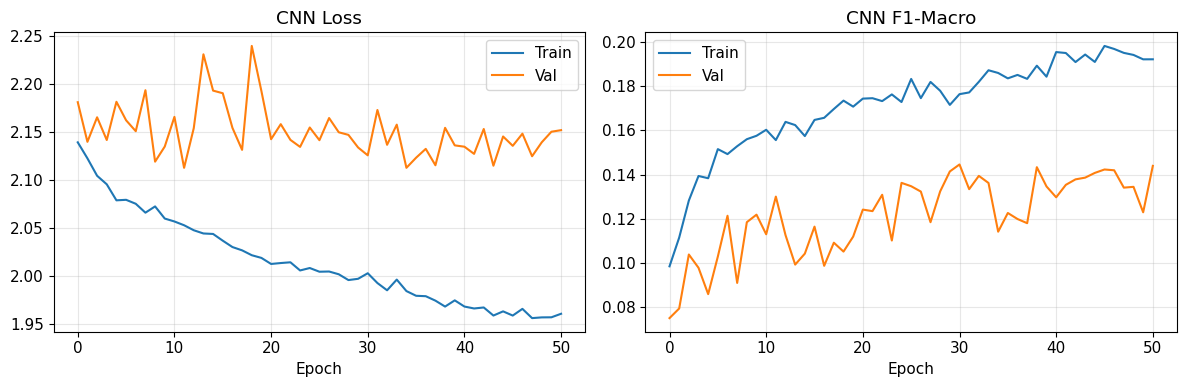

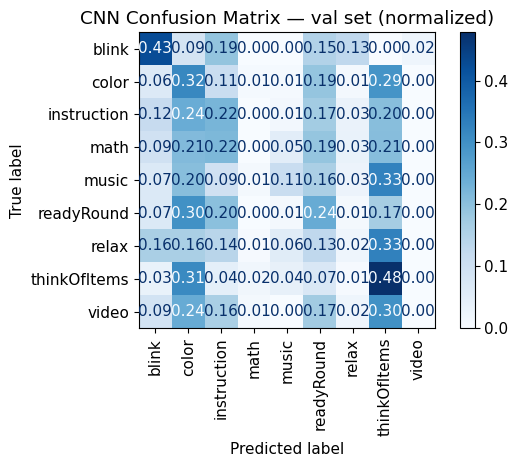

In [220]:
# ── CNN model: (B, 6, 8, 8) → num_classes ────────────────────────
class EEGMatrixCNN(nn.Module):
    def __init__(self, in_channels=6, num_classes=9):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(in_channels, 32,  kernel_size=3, padding=1),  # → (B,32,8,8)
            nn.BatchNorm2d(32),  nn.ReLU(),
            nn.Conv2d(32,         64,  kernel_size=3, padding=1),   # → (B,64,8,8)
            nn.BatchNorm2d(64),  nn.ReLU(),
            nn.Conv2d(64,         128, kernel_size=3, padding=1),   # → (B,128,8,8)
            nn.BatchNorm2d(128), nn.ReLU(),
            nn.AdaptiveAvgPool2d(1),                                 # → (B,128,1,1)
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128, 64), nn.ReLU(), nn.Dropout(0.4),
            nn.Linear(64, num_classes),
        )

    def forward(self, x):
        return self.classifier(self.features(x))

cnn_model     = EEGMatrixCNN(in_channels=6, num_classes=num_classes).to(device)
cnn_optimizer = optim.Adam(cnn_model.parameters(), lr=3e-4, weight_decay=1e-4)
cnn_criterion = nn.CrossEntropyLoss(weight=cw_cnn)
cnn_scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    cnn_optimizer, mode='max', factor=0.5, patience=5, min_lr=1e-5)

print(cnn_model)
print(f"Trainable parameters: {sum(p.numel() for p in cnn_model.parameters() if p.requires_grad):,}")

# ── Training loop ─────────────────────────────────────────────────
cnn_num_epochs       = 100
cnn_best_f1          = -1.0
cnn_best_epoch       = 0
cnn_best_weights     = None
cnn_patience         = 20
cnn_patience_counter = 0
cnn_min_delta        = 1e-4
cnn_history          = {'train_loss': [], 'val_loss': [], 'train_f1': [], 'val_f1': []}

for epoch in range(1, cnn_num_epochs + 1):
    # — Train —
    cnn_model.train()
    tr_loss, tr_preds, tr_targets = 0.0, [], []
    for xb, yb in train_loader_cnn:
        xb, yb = xb.to(device), yb.to(device)
        cnn_optimizer.zero_grad()
        logits = cnn_model(xb)
        loss   = cnn_criterion(logits, yb)
        loss.backward()
        nn.utils.clip_grad_norm_(cnn_model.parameters(), 1.0)
        cnn_optimizer.step()
        tr_loss += loss.item() * len(yb)
        tr_preds.extend(logits.argmax(1).detach().cpu().numpy())
        tr_targets.extend(yb.cpu().numpy())

    tr_loss /= len(y_tr_img)
    tr_f1    = f1_score(tr_targets, tr_preds, average='macro', zero_division=0)

    # — Validate —
    cnn_model.eval()
    va_loss, va_preds, va_targets = 0.0, [], []
    with torch.no_grad():
        for xb, yb in val_loader_cnn:
            xb, yb = xb.to(device), yb.to(device)
            logits  = cnn_model(xb)
            va_loss += cnn_criterion(logits, yb).item() * len(yb)
            va_preds.extend(logits.argmax(1).cpu().numpy())
            va_targets.extend(yb.cpu().numpy())

    va_loss /= len(y_va_img)
    va_f1    = f1_score(va_targets, va_preds, average='macro', zero_division=0)

    cnn_scheduler.step(va_f1)
    cnn_history['train_loss'].append(tr_loss)
    cnn_history['val_loss'].append(va_loss)
    cnn_history['train_f1'].append(tr_f1)
    cnn_history['val_f1'].append(va_f1)

    improved = va_f1 > cnn_best_f1 + cnn_min_delta
    if improved:
        cnn_best_f1, cnn_best_epoch = va_f1, epoch
        cnn_best_weights = {k: v.cpu().clone() for k, v in cnn_model.state_dict().items()}
        cnn_patience_counter = 0
    else:
        cnn_patience_counter += 1

    if epoch % 5 == 0 or epoch == 1 or improved:
        tag = '  <- best' if improved else ''
        print(f"Epoch {epoch:3d}/{cnn_num_epochs} | "
              f"TLoss: {tr_loss:.4f}  TF1: {tr_f1:.4f} | "
              f"VLoss: {va_loss:.4f}  VF1: {va_f1:.4f} | "
              f"LR: {cnn_optimizer.param_groups[0]['lr']:.2e}{tag}")

    if cnn_patience_counter >= cnn_patience:
        print(f"\nEarly stop at epoch {epoch}  "
              f"(best: epoch {cnn_best_epoch}, val F1: {cnn_best_f1:.4f})")
        break

if cnn_best_weights is None:
    cnn_best_weights = {k: v.cpu().clone() for k, v in cnn_model.state_dict().items()}

cnn_model.load_state_dict({k: v.to(device) for k, v in cnn_best_weights.items()})
print(f"\nRestored best checkpoint — Val F1-macro: {cnn_best_f1:.4f}")

# ── Final evaluation ──────────────────────────────────────────────
cnn_model.eval()
cnn_final_preds, cnn_final_targets = [], []
with torch.no_grad():
    for xb, yb in val_loader_cnn:
        logits = cnn_model(xb.to(device))
        cnn_final_preds.extend(logits.argmax(1).cpu().numpy())
        cnn_final_targets.extend(yb.numpy())

print("\nClassification Report (CNN — 6-matrix images):")
print(classification_report(
    cnn_final_targets, cnn_final_preds,
    target_names=le.classes_, zero_division=0))

# ── Training curves ───────────────────────────────────────────────
fig, axs = plt.subplots(1, 2, figsize=(12, 4))

axs[0].plot(cnn_history['train_loss'], label='Train')
axs[0].plot(cnn_history['val_loss'],   label='Val')
axs[0].set_title('CNN Loss');    axs[0].set_xlabel('Epoch')
axs[0].legend(); axs[0].grid(alpha=0.3)

axs[1].plot(cnn_history['train_f1'], label='Train')
axs[1].plot(cnn_history['val_f1'],   label='Val')
axs[1].set_title('CNN F1-Macro'); axs[1].set_xlabel('Epoch')
axs[1].legend(); axs[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

# ── Confusion matrix ──────────────────────────────────────────────
ConfusionMatrixDisplay.from_predictions(
    cnn_final_targets, cnn_final_preds,
    display_labels=le.classes_,
    xticks_rotation=90,
    normalize='true',
    values_format='.2f',
    cmap='Blues',
)
plt.title('CNN Confusion Matrix — val set (normalized)')
plt.tight_layout()
plt.show()
